# Lesson 158 · Year 4 synthesis

Standalone CPU audit. PROVIDED cells expose the computation; TODO cells implement three claim guards; CHECK cells give immediate feedback; EXIT exports your evidence and written defense. Author solution is not learner mastery. Links point to the course site and may remain unavailable until publication; all replay inputs are embedded.

## 1 · Turn a portfolio into an argument

**Reading route.** Separate the thesis questions → read the matched result → trace evidence reuse → state counter-evidence → propose a falsifier.

**Your win:** write a defensible interim verdict on the mission: does learning directly from relational structure deliver value beyond manual feature engineering? Spend about 20 minutes on this lesson, then 45–60 minutes on the replay and a 700–1,000-word essay. The essay is your work; the executed solution is author evidence.

[L154](https://avistian.github.io/relational/lessons/0154-portfolio-synthesis.html) assembled results. [L155](https://avistian.github.io/relational/lessons/0155-compare-manual-fe.html) added a matched FE comparison. [L156](https://avistian.github.io/relational/lessons/0156-temporal-leakage-audit.html) separated timestamp filtering from historical availability. [L157](https://avistian.github.io/relational/lessons/0157-open-source-contribution.html) packaged a contribution. A reviewable package now lets us ask a harder question: **what should a skeptical reader believe after seeing it?** More artifact checks do not automatically strengthen the broad thesis.

Recall the earlier weakness work in [L137](https://avistian.github.io/relational/lessons/0137-error-analysis-reg.html) and [L149](https://avistian.github.io/relational/lessons/0149-weakest-relbench-tasks.html): a proposed explanation must survive a held-out check. Those lessons are conceptual callbacks here, not extra numerical samples in this report. The planned graph-construction Lesson 157b is absent; we cannot use its planned experiment as evidence. This lesson introduces no new architecture.

**Prerequisites in one sentence each:** a query is `(entity, cutoff)`; validation selects the recipe/checkpoint; test evaluates the frozen choice; MAE is lower-is-better; training-seed SD is not uncertainty across databases.

Retrieve: what identifies a query; which split selects a checkpoint; what does seed SD measure?

## 2 · Separate four questions before drafting

| Question | Evidence needed | Current local boundary |
|---|---|---|
| Does the pipeline run reproducibly? | Pinned inputs, complete runs, rescored predictions | Selected saved-prediction replay passes |
| Does RDL predict better than FE? | Matched task, information, evaluation and comparison budget | One matched F1 task; no decisive advantage |
| Does it save human effort? | Prospectively recorded comparable human work | NOT_OBSERVED |
| Does this establish broad undervaluation? | Generalization plus evidence about value and adoption | Research hypothesis; no market/adoption study |

The primary reading is [RelBench v1, Section 6 and Appendix C](https://arxiv.org/html/2407.20060v1#S6). It reports a study of predictive quality and human work. Treat that as **published evidence**, with the paper's own scope. Our selected replay does not recreate that human study. Its basic regression GNN also differs from the boosted regression comparison; the [L155 protocol](https://avistian.github.io/relational/labs/l155-reproduction.md) records the distinction.

A good synthesis does not make the strongest sentence it can phrase. It makes the strongest sentence its evidence can support, then says which experiment would change it.

## 3 · Work through one measured claim

Predict before reading: does a small mean difference prove equivalence? Write your reason.

| Evidence | Measured result | Permitted interpretation |
|---|---|---|
| L151 classification | 69.2588% AUROC | Execution evidence; fresh FE missing |
| L152 regression | 3.970840 MAE | Execution evidence; use L155 for matched FE |
| L153 recommendation | Test NOT_RUN | INCOMPLETE; validation pilot cannot fill test |
| L155 matched F1 | FE 3.948917; RDL 4.013141 MAE | Point estimate favors FE |
| L155 benefit FE − RDL | -0.064225; conditional 95% [-0.312329, +0.172961] | Neither superiority nor equivalence established |
| Human effort | NOT_OBSERVED | No local effort-saving ratio |
| L156 released → fixed horizon | 4.128265 → 4.200381 MAE | Policy verdict FAIL → NOT_ESTABLISHED; no leak-free sign-off |
| L157 released → fixed horizon | 4.015191 → 4.073480 MAE | Policy verdict FAIL → NOT_ESTABLISHED; no leak-free sign-off |

The F1 comparison uses the same held-out query population and five complete runs per method. A positive **benefit** means RDL has lower error:

`benefit = FE MAE − RDL MAE ≈ 3.948917 − 4.013141 ≈ −0.064225 positions`.

The benefit is computed from unrounded scores. Subtracting the two displayed six-decimal means gives −0.064224; the last-digit difference is rounding.

That point estimate favors FE. The 95% driver-cluster bootstrap interval is approximately **[−0.3123, +0.1730]**. It keeps a driver's cutoff queries together and is conditional on the already fitted models and this split. It does not cover new databases, all training randomness, or shared race/time dependence. An interval spanning zero does **not** prove the methods equivalent. See the [replayed evidence](https://avistian.github.io/relational/labs/evidence/l158/report.json) and [L155 uncertainty protocol](https://avistian.github.io/relational/labs/l155-reproduction.md).

<figure class="route-figure" tabindex="0">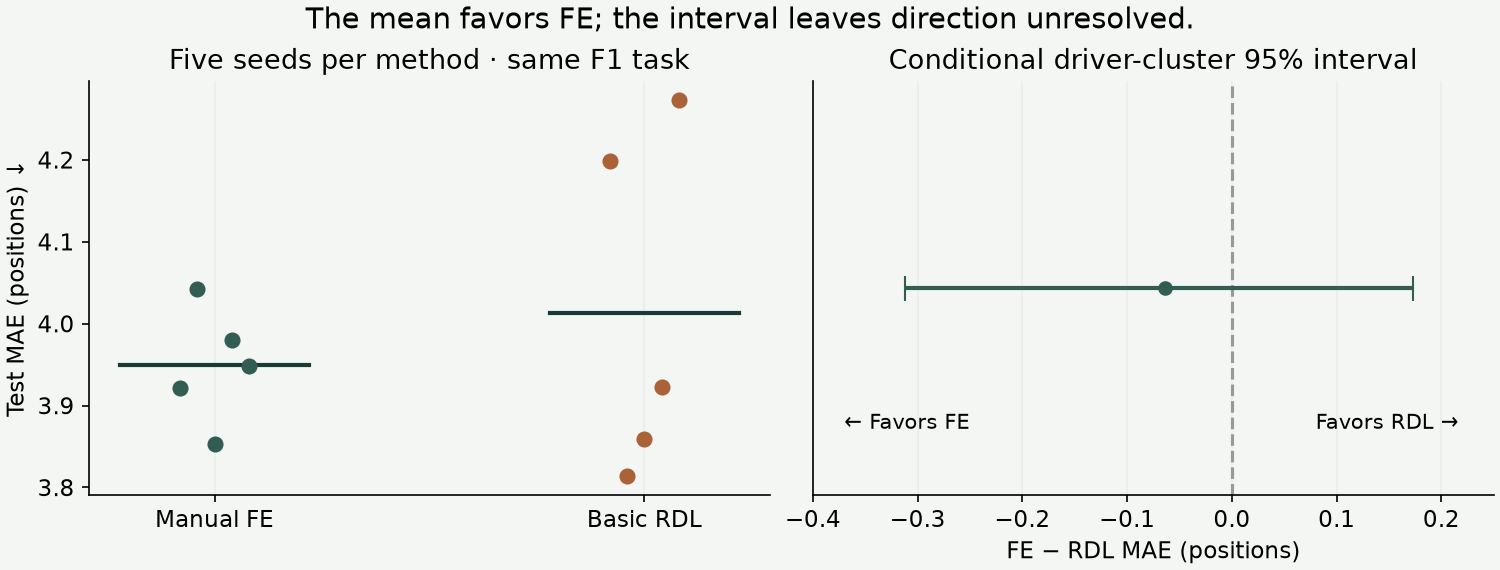<figcaption>Actual L155 test scores. Dots are training seeds; horizontal bars are means. The interval resamples drivers, conditional on fitted models, and crosses zero.</figcaption></figure>

**Worked rewrite.** “RDL beats feature engineering” becomes: “On our one matched F1 task, FE had lower mean test MAE by 0.0642 positions; the conditional interval did not resolve a consistent direction. This result does not establish a portfolio-wide RDL advantage.” The revised sentence names the population, magnitude, uncertainty and scope.

**Lab task — `claim_verdict`.** Map a requested claim to the evidence it requires. The function is a guard against overclaiming, not an essay grader or a significance test. Your actual essay still needs reasoning.

Hold the F1 scores fixed. Ask for a local quality claim, a portfolio claim, an effort claim and a legality claim. Explain why those require different evidence. Repeating the report five times adds no new task.

## 4 · Do not count a report as another experiment

Follow this chain: L151 seed-0 predictions → L154 portfolio report → L158 essay. These are three artifacts describing **one** prediction packet. Now contrast L155, L156 and L157: fresh predictions can differ, yet all concern the same F1 task and database. Distinct bytes are not proof of independent scientific replications or new-domain coverage.

<figure class="route-figure" tabindex="0">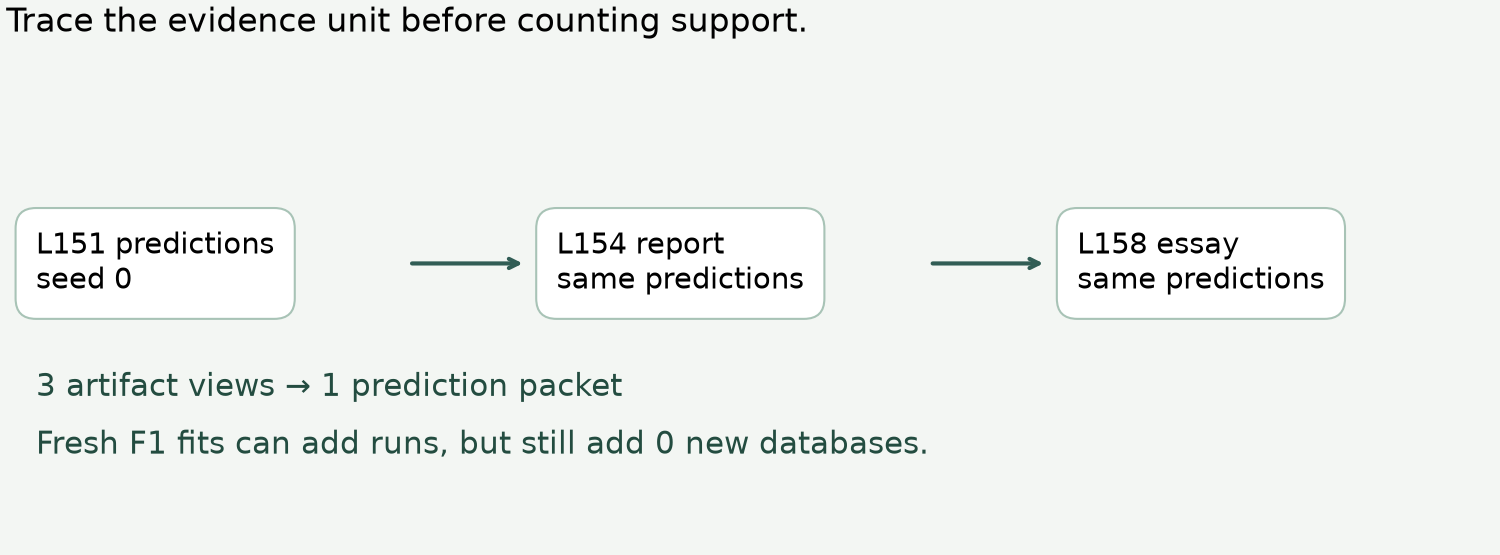<figcaption>L154 and L158 reuse the L151 predictions. New F1 runs still evaluate the same task and database; file counts are not independent-domain counts.</figcaption></figure>

**Lab task — `evidence_coverage`.** Count completed test tasks and databases once; group identical prediction hashes. Reject duplicate evidence IDs and validation pilots passed off as test entries. The report includes an explicit alias for the L154 view of L151 seed 0 so that you can see reuse rather than merely read a warning.

The completed portfolio covers **two tasks on two databases**, with **one matched FE task**. Recommendation remains incomplete. The 98,918 rescored rows include repeated evaluation populations, multiple seeds and a validation pilot; they are not 98,918 independent tests of the thesis. Never average AUROC, MAE and MAP into a headline score.

## 5 · A validity correction answers a different question

L156's released/fixed-horizon test means are **4.128265 / 4.200381 MAE**; L157's are **4.015191 / 4.073480**. These are separate execution cohorts, not four interchangeable methods to rank by the best test number. Each fixed-horizon intervention changes dated preprocessing to respect the declared 2005 fitting boundary.

The inherited policy verdict changes from **FAIL** for released preprocessing under that strict policy to **NOT_ESTABLISHED** after correction. Missing historical arrival information prevents a leak-free sign-off. A score can worsen while a declared policy is better respected. Neither observation explains every cause of performance. Source nonfinite-gradient observations also remain unresolved; reproducing a score does not certify healthy optimization. [L156 evidence](https://avistian.github.io/relational/labs/evidence/l156/report.json) · [L157 evidence](https://avistian.github.io/relational/labs/evidence/l157/report.json).

L158 freshly checks prediction metrics, keys and checkpoint selection. It **inherits**, rather than re-executes, the pinned SQL, sampling, gradient and availability audits. The [manifest](https://avistian.github.io/relational/labs/evidence/l158/input-manifest.json) names those files. Hashes demonstrate unchanged captured bytes, not the correctness of every upstream judgment or historical identity.

## 6 · Reproduce every numerical premise used here

**Named experiment:** `L158 Year 4 thesis evidence replay`. Full selected scope: classification reference and selected lanes, regression, recommendation validation pilot, the matched FE/GNN comparison, and both temporal-policy lanes in L156 and L157. No test missingness is replaced with a pilot score. The selected classification lane remains separate from the reference lane.

**Executed author evidence:** 98,918 rows rescored, 45 validation-selection checks and 220 frozen inputs. No fresh training. These counts describe audit work, not independent scientific replications.

```bash
# From relational/. CPU only; no downloads, fitting or cloud dispatch.
.venv/bin/python labs/_replay_l158.py
.venv/bin/python labs/_verify_l158.py
```

The verifier uses independent sklearn metric calculations and a separate bootstrap implementation. Complete `(entity, cutoff)` alignment includes explicit seconds-to-nanoseconds conversion for temporal-label packets. Checkpoint selection is validated against saved validation histories. Fresh training commands and their original boundaries remain in [L151](https://avistian.github.io/relational/labs/l151-reproduction.md), [L152](https://avistian.github.io/relational/labs/l152-reproduction.md), [L153](https://avistian.github.io/relational/labs/l153-reproduction.md), [L155](https://avistian.github.io/relational/labs/l155-reproduction.md), [L156](https://avistian.github.io/relational/labs/l156-reproduction.md) and [L157](https://avistian.github.io/relational/labs/l157-reproduction.md).

**Budget:** USD0 new cloud spend; no fresh training. This is full replay of the declared evidence set, not whole-paper reproduction. The recommendation run remains INCOMPLETE; the original human study remains NOT_RUN. The local contribution remains PENDING_PUBLICATION.

## 7 · Write a claim that could lose

**Lab task — `validate_falsifier`.** Specify the task, comparator, information policy, metric direction, minimum useful benefit, validation selection rule and test decision rule. A complete form is only SPECIFIED_NOT_EXECUTED, not a well-powered research design by itself.

**Illustrative future test, not an executed result:** on a predeclared task from a new held-out database, compare RDL against SQL features plus LightGBM under the same information boundary. Choose a useful benefit threshold before test access; for a finishing-position task, 0.1 MAE could be a planning example, not a universal threshold. Freeze model selection on validation. An upper benefit-interval bound below that threshold would disconfirm the claim of a benefit at least that large. Specify budget fairness, seeds, cluster unit and interval method before running. Measure human effort separately and prospectively; a runtime timer cannot substitute for it.

The missing graph-construction experiment is another possible follow-up, but do not presume its result. L159's foundation-model preview will introduce a new research direction; this essay must not borrow that future promise as present evidence.

## 8 · Your synthesis essay

Use the [essay template](https://avistian.github.io/relational/labs/l158-essay-template.md) and the [student notebook](https://avistian.github.io/relational/labs/0158-year-4-synthesis.ipynb). The [executed author solution](https://avistian.github.io/relational/labs/html/0158-year-4-synthesis.html) demonstrates the audit, not your mastery.

1. **Verdict:** one bounded paragraph defining which part of the thesis you are testing.
2. **Evidence for:** distinguish published support from locally reproduced execution; cite exact artifacts.
3. **Evidence against or unresolved:** use the matched F1 result, missing effort observations and incomplete recommendation entry.
4. **Validity and dependence:** explain the temporal audit and why repeated seeds/reports add no new database.
5. **Falsifier:** propose the next experiment and the result that would change your mind.

Score 0–2 on each of five axes: numerical/provenance accuracy, comparator fairness, uncertainty/dependence, counter-evidence, and an operational falsifier. A review target is **8/10 with no zero**. Automated checks cannot grade your reasoning; send the essay to the teaching agent for feedback. Learner status remains PENDING_WRITTEN_DEFENSE.

Explain the gap between computational replay and a broad thesis claim in your own words. Ask the teaching agent to review it.

**Spaced retrieval:** tomorrow, reconstruct the four-question table without opening this page. In a week, rewrite an unsupported “RDL wins and saves time” claim using only the evidence you can recall, then check the report. Ask the teaching agent about anything unclear and bring your written defense for review.

[Quick reference](https://avistian.github.io/relational/reference/year-4-synthesis.html) · [Previous lesson](https://avistian.github.io/relational/lessons/0157-open-source-contribution.html) · [Course](https://avistian.github.io/relational/index.html)


In [1]:
# @colab-bootstrap — PROVIDED: Python3.10+ and numpy. No downloads or training.
import base64,gzip,hashlib,json,math,statistics,zlib
from datetime import datetime
from pathlib import Path
import numpy as np
ROOT=Path('l158-packet')
ROOT.mkdir(exist_ok=True)


In [2]:
# PROVIDED: compressed, hash-pinned author evidence; not a model or task solution.
PACKED = '...'
manifest = {'experiment': 'L158 Year 4 thesis evidence replay', 'freeze_date': '2026-10-01', 'files': {'_replay_l154.py': '49f314c0d24d85c47546b64d7d491c1392e62605d756e1d00d4dd2b9f39836e0', '_report_l155.py': '5f16742c97b39f815f45988621e6d4e773df93c9fbb8173fcb290cbba05ca239', 'evidence/l151/frozen.json': 'bc94f4831f1ac9c450f41e1bc7a38dcfa7688a606c04ef4b81c7283b5eed467d', 'evidence/l151/prepared/queries.npz': 'c6f389fa158af01679b3731b7ab7daa98151c4e878dbca015ca8acde81c69a22', 'evidence/l151/prepared/task_audit.json': '9295489f0c660840660793b7eb2583e3d885ccc85cfdf73e2049738418803c74', 'evidence/l151/ref-0/predictions.npz': '51d0ce3987294ccda80c6bcb6b584c54604558365a5b5f38f1c9fd79def664c6', 'evidence/l151/ref-0/result.json': '02ef22fd0530672abc865b97b5da4614bbeba9ba842eecd8ae347678640d2c0b', 'evidence/l151/ref-1/predictions.npz': '7a903df9895bda841fd43f4560f4e37b8cd095bdfec3e4b6451aa056463f58fd', 'evidence/l151/ref-1/result.json': '5d41f9ddddb0b0ca5ae87bdedd72867af04323357bfbfb50a12690e841280ea8', 'evidence/l151/ref-2/predictions.npz': '35461ada128f5c814472c6970b859e1dc67ab816ec10fa77b965864b1c658a18', 'evidence/l151/ref-2/result.json': 'a50d3972a70b291b696dc9d7549ad3d8fcdafc09111f875ccbe3d1dc906ad886', 'evidence/l151/ref-3/predictions.npz': 'e7ec1ab718e995fa85c1d7b445f531da6e62e98a72030e6c1f5f416b5c3ec9fe', 'evidence/l151/ref-3/result.json': '069fa21a53b5fd7e09c4e69df25da3e2730d8b116b90ffcf0912765e741dc637', 'evidence/l151/ref-4/predictions.npz': '2fc5bba0d33e05d6e87f3dacdf63bfc89a7b75d7c3891eea60b4a50aad0933c6', 'evidence/l151/ref-4/result.json': '7e498a8110d62328ab6ce3fc91e5caaed6497220d782aa74f087284ffd22a874', 'evidence/l151/selected-10/predictions.npz': 'fba90fafdd4da1d07570aeceb9e3d9009851c94f0a23b30b034c612506055246', 'evidence/l151/selected-10/result.json': 'ce0066cb9932d9af01017330514e6f851ece6847d338322ad062248b4dc39313', 'evidence/l151/selected-11/predictions.npz': '209eb51358582b3f471093e7a9be6a2d71e6cc306d28219b0a88190f27ff1be5', 'evidence/l151/selected-11/result.json': '267b59ce26a9c4ea80d4a845f19d9e4b688aa2b2b5e48710562041e3201d5e83', 'evidence/l151/selected-12/predictions.npz': '2e0d1c2f20c3e33259c902b9d71c61d76b38efc8544dd286547d90dc964573fb', 'evidence/l151/selected-12/result.json': '8d3e977580e166a4677b9fe87266be50bbbde90a98bc7c49b1e89cbd8dc666d4', 'evidence/l151/selected-13/predictions.npz': '48903a0724d910a10fe69b4756f85927956d320dfcd7ff9935bce0fcc38196f5', 'evidence/l151/selected-13/result.json': 'f9876c1a76104dfeede92eec60d75812752b9dd3750e9888cfefb81d85ff6714', 'evidence/l151/selected-14/predictions.npz': 'af4b726548a266fba5292edb1baf481d041dcf0f2a079052d0c8539fc3da88e0', 'evidence/l151/selected-14/result.json': '145aa85644df8a2616402df0fe28496689d413619256c7e988afa10f35a576b6', 'evidence/l152/label-audit.json': '4b8bfe28e9f0a5d3b1b35bdeb365f1b32f01f355f940de40e8f53fc983f82c23', 'evidence/l152/paper/seed-0/completed.json': 'a40f8634852919e411c073f43a00b5af05b4f1c6d691f399f20f7b2d30286810', 'evidence/l152/paper/seed-0/predictions.npz': '37935143a9d89f1e4324fae5b47cd4a09b1201f73e25eef98727737fdd4cbf78', 'evidence/l152/paper/seed-0/result.json': 'fd3caf154e09b56d4e1cc09177b2ff34c483d1f8698b8673099df0434acfa231', 'evidence/l152/paper/seed-0/temporal-audit.json': 'd58355173c7eeb0ca8a16bb7109318cecc9c2994db1e5243a83ea6bf16e5b689', 'evidence/l152/paper/seed-1/completed.json': '372d12baaf4ba4ef5037caf3fe48d437ab79f60a17f466e53761e99e2ab235f3', 'evidence/l152/paper/seed-1/predictions.npz': '40969d6664e2541106013b8d86f751fbbeaff031234c2e94b68a3db7fa792d5a', 'evidence/l152/paper/seed-1/result.json': '95b03b18698e798d657558611c9bf7c4e6b0f64858561a0800610fb97d391d9a', 'evidence/l152/paper/seed-1/temporal-audit.json': 'e78947ded054e6fb6538cb0df20e1a3215e579d3f22a5ceb1bb81a7e02600a68', 'evidence/l152/paper/seed-2/completed.json': '9049cb47193e4203cfa7d2491efa1917496b33b0c7f0d19a98e6a9216bcf7ef5', 'evidence/l152/paper/seed-2/predictions.npz': '60827c6d935ea8e67db3f94ba9886c4133e275ed2c9791c9e92fee2639a9dcb9', 'evidence/l152/paper/seed-2/result.json': 'bd45cc4074384b3cfe8e9d0813329c99463f2ac9ad52fe9678778afb25c7e297', 'evidence/l152/paper/seed-2/temporal-audit.json': '58245fa0615fcbc80e831af8df6a66fb31e2876d8a8cdb47f427edfd9cd6ec34', 'evidence/l152/paper/seed-3/completed.json': 'd38061eb254b0880b46f028868ad6b79dc7049fd7fedebcbe3fe41a07b86a6c7', 'evidence/l152/paper/seed-3/predictions.npz': 'f9da76d067653c22aad42953447d66c941e57a05327888cb64c57c4aa1299c81', 'evidence/l152/paper/seed-3/result.json': '64a568e5c68fe1e10b616982c91922a4735afe3d1371a361c19dc70d23660c1d', 'evidence/l152/paper/seed-3/temporal-audit.json': 'c445bc48111908707d812e711bb4b73310497f70bec7dbf484486b26fee3497f', 'evidence/l152/paper/seed-4/completed.json': '969bdc86f6c5e29e5d0c03be3f63dac829e10dbd271b54949ac0df74fab0d53c', 'evidence/l152/paper/seed-4/predictions.npz': 'da898b061ffdaf4214c7ac51de23f9377aac0e1215fae2a3da2068aca9e9c9a2', 'evidence/l152/paper/seed-4/result.json': '196cd9f47fabb06a5714deeb906f82b8fd72ec3ad848992c429301de7d4306ef', 'evidence/l152/paper/seed-4/temporal-audit.json': '0aa93e28e719f61b62544b731debbfe20de095e56a9f6863cf1c5d618fc75dfa', 'evidence/l153/cost-decision.json': 'bbb083b02dd531cdb9d248a99d0e72e8e738fcc404bf59c7e036979e7c08567f', 'evidence/l153/pilot/predictions.npz': 'f1e5a07e60262d30ff5a7713ad6151f91f3507683a328ad267ef6aa2257b9555', 'evidence/l153/pilot/result.json': 'f0041ce48f981052ac0838eff93ba9260afaea1a84a4a60c32d4f67bc08c7677', 'evidence/l153/prepared/val-truth.json.gz': '7aa1f02a593e2d0b5c85bf9b2fb92eaa9684dbb4fe14aaef353ac42e2ea11d5c', 'evidence/l154/input-manifest.json': 'b2b8ed1be3f1c4e664501ef0c1a34e141767e3980db4578baa02d88a0c21e8cc', 'evidence/l154/published-context.json': 'd57df198c73e27cc649dde699a671ff6b253a4840d3e912776dc5b4bbacf92d6', 'evidence/l154/published-tables.html': '0c0b8dca49e50de2ad796e00e7f1e06c1754f9aa5fc8bdcfecef5c510ac6068c', 'evidence/l154/report.json': '7afce1049c44cbde71f8d64a2d67d9b44613558d4f471c2d1feb44b36c659f32', 'evidence/l155/effort-log.json': 'eeb417c113c851c677fb13625c4a3f589e2bb8ecc59438fb6305010a4231909c', 'evidence/l155/fe/paper/seed-0/predictions.npz': '5be06f8d4fe047168b8bf5fbbcbd55bfb4efe0ec586a7a015e83b77429c67b1a', 'evidence/l155/fe/paper/seed-0/result.json': 'a50cc0ee0905b725e3c31da7efe71714e9d585feb6348bc2cb5cb2d1583b366e', 'evidence/l155/fe/paper/seed-1/predictions.npz': '77f8bf6e78b3781f58a7f46b24692393820b9900e73306a9906337b3752d4d0c', 'evidence/l155/fe/paper/seed-1/result.json': '6d5a76b9ed09ea745d3af0174f7bfabaa1a4da51aebf7353117c2abaa234d67e', 'evidence/l155/fe/paper/seed-2/predictions.npz': '9cf251f9a0ca74ef417c8960422a81bcfdbaf015568e50106c1dc65a41ab6400', 'evidence/l155/fe/paper/seed-2/result.json': '7c518181df6f9c61a89b668233820debf2273d74314c6655d10bc80c80d30867', 'evidence/l155/fe/paper/seed-3/predictions.npz': '8352fa0bf90389cb69a48b1600263388f1cd702c6e1a3328713407d4ca54bcb7', 'evidence/l155/fe/paper/seed-3/result.json': '5ac2d1d4c3921f66d6238cbeb411c6dba9a50f502e1d094b6779d8fdba6640f9', 'evidence/l155/fe/paper/seed-4/predictions.npz': '76003123d6177edfddf9cc47c1e3ed6a832c1d8516569bf0105eb34fd465aa4c', 'evidence/l155/fe/paper/seed-4/result.json': '3b1c05b5c7fd39653153c574d399f3485bd8f773782e1042b90660f4c5b23d77', 'evidence/l155/fe/preparation.json': '0af41cd256418405e53fcf6ecbb1df3e9e3576e4a4c8eef324cf8fc7c112db56', 'evidence/l155/fe/sql-audit.json': '7f006d060809cb60034d8f81f315e80e85f786ee95d994a918c92e96a06ca97b', 'evidence/l155/fe/summary.json': 'e32d798bf9a301ab3b2a5d2d62cce136bb8c1f9b50b9cbdf6a89dcd44abad9af', 'evidence/l155/frozen-_budget_l155.json': '42ca53c89d6087f28c3b722a9c6af1363c59721d8e3bf9a99eb85127a88d24dc', 'evidence/l155/frozen-_sources_l155.json': 'a355d33472caef99fa5e76e17784c93b62acef744432afe8fa31ddc0549f54e2', 'evidence/l155/frozen-_upstream_l155.json': 'd70f0720658e6b718f95430df755533a33eaf9e57602030125fe7bcf37242af0', 'evidence/l155/input-manifest.json': '7cc29977e5cb92c9986aba9b34199ad806f046c15776acb72a9431f39bfc379a', 'evidence/l155/label-audit.json': '4b8bfe28e9f0a5d3b1b35bdeb365f1b32f01f355f940de40e8f53fc983f82c23', 'evidence/l155/paper/seed-0/predictions.npz': 'f557c9d3c3e4e81f10d69cb66111007d68e3f0460c85c19524f3f06ab1e9aa32', 'evidence/l155/paper/seed-0/result.json': '55e0ed199482fbb43fdc0eee7ebe5ed3c84bc32306084dcb86d1523f776f2d0b', 'evidence/l155/paper/seed-1/predictions.npz': '916e412b6b5bbcb06d727b1c3ddf51735b0962c0b904446cdc9e9eb5b48de797', 'evidence/l155/paper/seed-1/result.json': 'd6408438443448e5de73a31a45e36e6073ece0b9927387a4369075d50a462604', 'evidence/l155/paper/seed-2/predictions.npz': 'bf766c582297d7349b0873b5b2643d56e4800fe05927c6314a8738e7959e6208', 'evidence/l155/paper/seed-2/result.json': '48aedf4fbe40945af48e3e6cdd9c3d51a28d61d94a2c2457702ce89a13fbca82', 'evidence/l155/paper/seed-3/predictions.npz': '45609f65ec20766d4b9e1918be77f8b928f049152f7da62419b2b47fd04839b1', 'evidence/l155/paper/seed-3/result.json': '95129431b958c584db1ff8d44b9754cbbbaba9a94814b353834502b4bece0517', 'evidence/l155/paper/seed-4/predictions.npz': '0ac4b50fb605808369d0429cf42aacea04901a033c7e70d766f5017e179393da', 'evidence/l155/paper/seed-4/result.json': '768dbc798f90fea9d0948282aa7cc27c54b56c374a1949d759360b3345a8ab67', 'evidence/l155/report.json': 'f531f16bb1b34afd111491ae5a59285ad16d20ec80fbac89b12ef5eb2001c6ea', 'evidence/l155/summary.json': '70e7ed7f0e42eeac1d18f0102bbda533662ed40da8ad2d8fddd4ef9702a8f3fa', 'evidence/l156/fit_horizon/seed-0/audit-l156.json': 'f8812b93166204eefd146ae8ccb840d351a858b3055ef9946553279060a002a6', 'evidence/l156/fit_horizon/seed-0/checkpoint-audit.json': '61af719392571cf0531ab8b8f2e092e3a45a23515b0230e12eb4160f40ceb188', 'evidence/l156/fit_horizon/seed-0/completed.json': '957774168bca2f88b547c15722f80c6bb565a59eb7205f8f464332d7a8650ba4', 'evidence/l156/fit_horizon/seed-0/diagnostics.json': '868154b9f8b137a16a94e71018607c9a3ba57aa1a2e6e74843f7d7d91bcd53dc', 'evidence/l156/fit_horizon/seed-0/predictions.npz': 'e639d34aa63d23b7985fa372274a942b8dcbe053fe03a0522d106cb9f0347126', 'evidence/l156/fit_horizon/seed-0/result.json': '65b1ebc4df627545b2dd303e53d249b97a6a92ec5b6b5fa8888ccf58aeefa5e5', 'evidence/l156/fit_horizon/seed-1/audit-l156.json': 'b9e254d5efde6e2bb75253b7ccc51722c3b316f7abbb0d48fc68b40bb265f55b', 'evidence/l156/fit_horizon/seed-1/checkpoint-audit.json': 'a31a67da345e48029c709c29131b08f4d6ba97df8e800eea5878bc0584c1e7dc', 'evidence/l156/fit_horizon/seed-1/completed.json': 'c7937be79469f5096379d63f05edb069bcbd8fad8de2aed7b140c9972464a6a4', 'evidence/l156/fit_horizon/seed-1/diagnostics.json': 'b1e4048d474bea276c8a8541934bc8dc628a3a87c428877908dd7e31511c747d', 'evidence/l156/fit_horizon/seed-1/predictions.npz': '13dd8a770f805999f0600b695f87691f7a69a1c85152175118c53a738b8380a3', 'evidence/l156/fit_horizon/seed-1/result.json': 'fb27f8a32a45c71557964de51eaa6dd8a537b8c0b2ad95b7923126a2df16edf9', 'evidence/l156/fit_horizon/seed-2/audit-l156.json': 'b9e254d5efde6e2bb75253b7ccc51722c3b316f7abbb0d48fc68b40bb265f55b', 'evidence/l156/fit_horizon/seed-2/checkpoint-audit.json': '96043ed89c3903ecebc1b4ff4a7f4e5611d074366f018a5fec25b799ba868652', 'evidence/l156/fit_horizon/seed-2/completed.json': '9e98b6130270759848c96f08b6807419c6c977984d28372d1121872b0a7a7c61', 'evidence/l156/fit_horizon/seed-2/diagnostics.json': '4dddb5b87a7a5f9305bae9c5159ffd9219700a1106e24d66decf89ee253ac9bf', 'evidence/l156/fit_horizon/seed-2/predictions.npz': '6d6d684e0b4c5529573507c1440c42ffc6ca7f5099992dc71b787d45a8f86e33', 'evidence/l156/fit_horizon/seed-2/result.json': '91da29325113c8f5fd313ff5e9b084b8d52be7e12879c82c71f3fe9607eb7f8f', 'evidence/l156/fit_horizon/seed-3/audit-l156.json': '36348c29e682fa96375a850273effe8e54a5575bc9189367526167f7f8234ffc', 'evidence/l156/fit_horizon/seed-3/checkpoint-audit.json': 'b7f66b6451931970e77ba320c97632d06f17edd76b62cb5f592de0629a092837', 'evidence/l156/fit_horizon/seed-3/completed.json': 'df4eb260a3c79c5876475067f6d388faa53dfe981984c7a9ce4b8b55eba912be', 'evidence/l156/fit_horizon/seed-3/diagnostics.json': '8f1c45ba504312c630f74ccf2ff359d4088f3f9a4cf5c3c6481584782fccf678', 'evidence/l156/fit_horizon/seed-3/predictions.npz': '9e995319995edeef51c87fb4c40a3a7c398847f11845df38cad0df8a4dcfcedd', 'evidence/l156/fit_horizon/seed-3/result.json': 'd83414b100bd4064cbe62102ba88d9cc2f54a0e6371be030196103ebd601ccbc', 'evidence/l156/fit_horizon/seed-4/audit-l156.json': 'dc056105522f6174457d33ab0fd60dfacd5af3bb86e7f492b684f73d898d2e4f', 'evidence/l156/fit_horizon/seed-4/checkpoint-audit.json': 'eca3c9451ab78b3a313be0a746943e86eb11a7d5b2aea64ee2862589f737c31c', 'evidence/l156/fit_horizon/seed-4/completed.json': 'a04f017ae7a7b8b3023f7bdb75c919f805cc995a40c2900412ee49f77ba67aa4', 'evidence/l156/fit_horizon/seed-4/diagnostics.json': '3884cf0bce512deced23ed7a8d476af64a32adb441ec308b63a4d753fab63b05', 'evidence/l156/fit_horizon/seed-4/predictions.npz': 'd16e25cb7eee7541b02da39f047fe6e847addbb12d9d66ee3520689ab56d9875', 'evidence/l156/fit_horizon/seed-4/result.json': 'd452bc182de888e66ef0c27860a36048069842e1c6fef14c461168289f207f32', 'evidence/l156/input-manifest.json': '1405c8275c0975696193c1f372de02af26399a756af008925e9b429082aa98a3', 'evidence/l156/paper/seed-0/audit-l156.json': '8a197ec863627827e302f5b7633766b1f51b483efe0c8f18989fe9d9be501ad9', 'evidence/l156/paper/seed-0/checkpoint-audit.json': '4a069c44ac8f84f35db3ab646a2e2e63facb7bd039835633b43c52ae19c35579', 'evidence/l156/paper/seed-0/completed.json': 'b6614a8a4fb40b2eecc8c87ef45f017dc03d04ee255894599fe3cfa6339741e0', 'evidence/l156/paper/seed-0/diagnostics.json': 'c76321e9a58d2c807f7edd1e77e80950d065bd76ba22aee552b95190c477d052', 'evidence/l156/paper/seed-0/predictions.npz': '6e4ddbba11a35931c42887d34c3f93b647692d3211f581079bc4abe33341e44a', 'evidence/l156/paper/seed-0/result.json': '83483695b55dab46f0eb0857523f4c90f7a5d0993cefa986c3058d82b6e0f59a', 'evidence/l156/paper/seed-1/audit-l156.json': 'a1def09c83961ac2f6c58bebf24929dfbe382f6da7962104eab5291fd21c5202', 'evidence/l156/paper/seed-1/checkpoint-audit.json': '7a61683e22f4a2a671f467729b4183c5b5825e513e33b2ac610c8cf7107226e3', 'evidence/l156/paper/seed-1/completed.json': '9bb89332732b55ac5a5cab0bb311dee6a964e45045b745d189d26d8b1b4c91aa', 'evidence/l156/paper/seed-1/diagnostics.json': '16a30c7af9f812693dc6f1c449e9aac298d51cfcebc3a05a57a26be45300933b', 'evidence/l156/paper/seed-1/predictions.npz': '5de33730ea4429db9ed6f54dbf0a3710ffae70c41a97c6c0af5fe242b5e0a061', 'evidence/l156/paper/seed-1/result.json': '9eef0417d1a4bee6bd04cbb9cb77dc1dc386f3b1b04e2cadec0dce83b45dd2bb', 'evidence/l156/paper/seed-2/audit-l156.json': '8a197ec863627827e302f5b7633766b1f51b483efe0c8f18989fe9d9be501ad9', 'evidence/l156/paper/seed-2/checkpoint-audit.json': '25d50ffc8d1df047320fc71e7235d4a6421de03f5ad85433aa74b1fdce931589', 'evidence/l156/paper/seed-2/completed.json': '5b651fe3e56120843644b6f702c1f66c1d46b12be86f863ba667bc23623d1851', 'evidence/l156/paper/seed-2/diagnostics.json': 'c490d9ab978382744990a2ca983a8ac7ca4e546e05f1ee86c98e9b900ce11d98', 'evidence/l156/paper/seed-2/predictions.npz': '640b82f3f7a8d345a9e6598e2ac4bc1fdfe8a08953cbc0af806a4631de4246dc', 'evidence/l156/paper/seed-2/result.json': 'ddc7456625d554b0a077f457acc175c4de58de2b302b8f758ae7c61f43b93294', 'evidence/l156/paper/seed-3/audit-l156.json': 'c85baee4b8d35ffd2ae77656d8fd0fa69bbdcbfbcc3bef8c2db16f7b3f2584d5', 'evidence/l156/paper/seed-3/checkpoint-audit.json': '59b722839a28706919d5bffdd57e73468f4e9af60bcea6faf88931e36d0bde51', 'evidence/l156/paper/seed-3/completed.json': 'fd72f3fb2f720ed3d1311b675a8f6c6c7a858700f7aee0977b81b231f5cd6cb6', 'evidence/l156/paper/seed-3/diagnostics.json': 'acce3dfeba13f2c929719488956357c635f778f8b8c8edf5c11932ca3dd0c4ab', 'evidence/l156/paper/seed-3/predictions.npz': '21c8b62837c044bf8f1b9ca0ce6f685d1f4d38bb20a06d831e41284b49186121', 'evidence/l156/paper/seed-3/result.json': '1e873e6f9eb5a1c1a53c7c10c30720e876b34f204765d12c6d61cce658fed640', 'evidence/l156/paper/seed-4/audit-l156.json': 'c85baee4b8d35ffd2ae77656d8fd0fa69bbdcbfbcc3bef8c2db16f7b3f2584d5', 'evidence/l156/paper/seed-4/checkpoint-audit.json': '21d52cb95c72f2153a1b8bf7d4d4c9fd86a8b88ad04ec43de4d5e4fdb45f5399', 'evidence/l156/paper/seed-4/completed.json': '69bb098465a1916cca3a1eb98751d5592f3743a4e734df8c8792ab5d02cdd1fa', 'evidence/l156/paper/seed-4/diagnostics.json': '1f38fb6664e770675faba2997b045035291accd2e20f0a1bc96a217b9a6fbdaf', 'evidence/l156/paper/seed-4/predictions.npz': '6d335d425c29938ff3cc4dc8db521b1241ad7b556d3de2e9a1b5e55f87f3b542', 'evidence/l156/paper/seed-4/result.json': '02163b455ffca3e855aba3b6d1ccaa9f90480eaefbc335e144b14032f49532ca', 'evidence/l156/report.json': '5bbd7c1a95a7abd75bbb4029cc4c77e76761b96f88282c16a337189ab4fcc7b1', 'evidence/l156/test-labels.npz': '50a2ad723b98cee1ea22a9f859c2529d7e1dc334d1a7a4d7d2910a6376fdab02', 'evidence/l156/val-labels.npz': '471f76059ca72f76600d473d1dbb7a8ea79cdae1bd7bb17c3ae42b1312592f22', 'evidence/l157/fit_horizon/seed-0/audit-l156.json': 'f8812b93166204eefd146ae8ccb840d351a858b3055ef9946553279060a002a6', 'evidence/l157/fit_horizon/seed-0/checkpoint-audit.json': 'ff0169e72de284316c14fc403c08ad463b0a6f0c7fcf2d05fe64e91c89e954b7', 'evidence/l157/fit_horizon/seed-0/completed.json': '757bf6fa6e703f07e7cb74d3c38e1e557efd0609b14c05df70be80cc2f0549a3', 'evidence/l157/fit_horizon/seed-0/diagnostics.json': '513051c87ce98713e115e5866167eefaf3ab3abf3923e8a71d8f3a0bba6c99d5', 'evidence/l157/fit_horizon/seed-0/predictions.npz': '399da079bb04a97fcd5b266849754bcf895dfcbde8dd09fe4e6e76d80152bde9', 'evidence/l157/fit_horizon/seed-0/result.json': '8bfe8b03f4cef665fc9d10e8ee1c09c1ed7b841a9e247f19095bb9b9997245e7', 'evidence/l157/fit_horizon/seed-1/audit-l156.json': 'b9e254d5efde6e2bb75253b7ccc51722c3b316f7abbb0d48fc68b40bb265f55b', 'evidence/l157/fit_horizon/seed-1/checkpoint-audit.json': '3b7d323de46d8884cd3af09984b23fb0982970aa360c184b7c8cbf94e997eceb', 'evidence/l157/fit_horizon/seed-1/completed.json': 'b43c6cc965f4aa1c17da4c759431fe2bc3ce21451384d8a856b08ff4289f5005', 'evidence/l157/fit_horizon/seed-1/diagnostics.json': '23c8719b060037f66b51abac586fc51993c99b3fb4d42236368eada8b56011b6', 'evidence/l157/fit_horizon/seed-1/predictions.npz': '3d1aa6efb6757fdaf1d315922d5889caabff8fd589c2989d215a76d5ca22ed55', 'evidence/l157/fit_horizon/seed-1/result.json': '522a993168f4a6ae72c01d79ea44667b5934cf9523a19241d602e0ecd8e58fd2', 'evidence/l157/fit_horizon/seed-2/audit-l156.json': 'b9e254d5efde6e2bb75253b7ccc51722c3b316f7abbb0d48fc68b40bb265f55b', 'evidence/l157/fit_horizon/seed-2/checkpoint-audit.json': '0ec2d2cb8deb7c040fa9cc10b98174eeadfdf25d87c2111726ee05e9333fca2d', 'evidence/l157/fit_horizon/seed-2/completed.json': '861fe794c15081fad72741c51a14a7f22bce5196909b9dfa325653979588b891', 'evidence/l157/fit_horizon/seed-2/diagnostics.json': 'd8d8789fc1b35224421e33ee46ec59ca54e741d24b46061a124a05e48d22a991', 'evidence/l157/fit_horizon/seed-2/predictions.npz': 'e9bf0dd5258524d5e5e57d9600034eeb359b3ec5605376f316f869ce90a324d4', 'evidence/l157/fit_horizon/seed-2/result.json': '6bcb12b074ef50dc6ffc96884a8c42de955f0df383c6827b883ca5277c2d7fb2', 'evidence/l157/fit_horizon/seed-3/audit-l156.json': '36348c29e682fa96375a850273effe8e54a5575bc9189367526167f7f8234ffc', 'evidence/l157/fit_horizon/seed-3/checkpoint-audit.json': '989a386f5ebd39705402a1225db342987e527cb334a95576e9add3da0dbbf50a', 'evidence/l157/fit_horizon/seed-3/completed.json': 'b8a4cc1021ef23a193a5ae91cb9d2348a45e873b2b4a81e1999428d2d17d293f', 'evidence/l157/fit_horizon/seed-3/diagnostics.json': '18899dbb1cfc0c7bc12f72ffe76761454b160b127cbc8a9697f480c69ebb9982', 'evidence/l157/fit_horizon/seed-3/predictions.npz': 'c69a5665b6469def28813977b1987247982da7dd79722566433400ef36c32786', 'evidence/l157/fit_horizon/seed-3/result.json': 'd0630b239e5e4032aded3dda3567be5d41f764ba29aafcf875863ba3d7c2afac', 'evidence/l157/fit_horizon/seed-4/audit-l156.json': 'dc056105522f6174457d33ab0fd60dfacd5af3bb86e7f492b684f73d898d2e4f', 'evidence/l157/fit_horizon/seed-4/checkpoint-audit.json': 'd2cd9040666664dd3ecf317f43c7db2d5a67e6f0762f8bc49d31237444573b1b', 'evidence/l157/fit_horizon/seed-4/completed.json': '64465d2a7896779e8275d0016b29512b96ff4af0b31383b01e192da966147d9c', 'evidence/l157/fit_horizon/seed-4/diagnostics.json': '25bdd25dc11d432dc9fe12dd30a2e9a6d2920fcd4f4b000107183a3716c9763a', 'evidence/l157/fit_horizon/seed-4/predictions.npz': '330690d3817866e270fd10ecf9efe1b7911958f2a8b8bcd72a7dee06c2e3aa5c', 'evidence/l157/fit_horizon/seed-4/result.json': 'a5edb5930e750fcc7507e1189fc5270f7fc2c92d08151136676f5a06e13dab77', 'evidence/l157/input-manifest.json': 'f5abedefa275fd9b771e8b4a33ba14bae877bdd9c4476fb9a3da57f04ecfdef7', 'evidence/l157/paper/seed-0/audit-l156.json': '8a197ec863627827e302f5b7633766b1f51b483efe0c8f18989fe9d9be501ad9', 'evidence/l157/paper/seed-0/checkpoint-audit.json': '37ff26fdb0fb1122d8b2534f474df0fdffcef585b5b96c75b250604446dda693', 'evidence/l157/paper/seed-0/completed.json': '8917d3bb5ac06cca154be158723ecaf9e595610284afb5eb3133b90d8ffaa21b', 'evidence/l157/paper/seed-0/diagnostics.json': '5ade7e622ffc69d2df49016a1b14f9cb0de048fad6e03a349197d298c4cb19a9', 'evidence/l157/paper/seed-0/predictions.npz': '5f488632a117d25a0e12aee3e0590cf6a51167529d351edb32ce454cca3ea242', 'evidence/l157/paper/seed-0/result.json': '32e8afbeda8f7f41cbfbe532015381df55dc584bc7517b545de3468130880e27', 'evidence/l157/paper/seed-1/audit-l156.json': 'a1def09c83961ac2f6c58bebf24929dfbe382f6da7962104eab5291fd21c5202', 'evidence/l157/paper/seed-1/checkpoint-audit.json': '3c078c816f1c47e92f1b90aeec01c9e1e2c155969f4f6485420a99f6b49c4953', 'evidence/l157/paper/seed-1/completed.json': '715b96fa0be65fb640adcc9d78d7614076e07096cbe8db00dcb8286e19242621', 'evidence/l157/paper/seed-1/diagnostics.json': '10083f9942d13d38ae1b7a093952779ea78898153cd347fb61cbac56351e4915', 'evidence/l157/paper/seed-1/predictions.npz': 'b96a422c491950b80d097a9283782954eef28eb999a525efe8a8d519956b8b84', 'evidence/l157/paper/seed-1/result.json': 'b4877765d17870e74f5d10e81cc9ee5fc87dbddeaac09efd039d36ef76d0e2ab', 'evidence/l157/paper/seed-2/audit-l156.json': '8a197ec863627827e302f5b7633766b1f51b483efe0c8f18989fe9d9be501ad9', 'evidence/l157/paper/seed-2/checkpoint-audit.json': 'a9229006081f3e06f8f32e9cbed5d65087cf187e3345fd76c6816bb176924720', 'evidence/l157/paper/seed-2/completed.json': 'ca15500f779d2fed2433ef0c303b8dd8f75d1fa31c3c83ab75f1f5ce11d2e615', 'evidence/l157/paper/seed-2/diagnostics.json': 'f6924117f6333bbca4613e4efda1779b7438818c5355dc9fc3623e24fde0ce50', 'evidence/l157/paper/seed-2/predictions.npz': 'a1daa05e0fbf475ab9e5fc7fda9e028763bbd14862290d4337e4baa2b1b3112b', 'evidence/l157/paper/seed-2/result.json': '348ac63b9b0e04479c5a230457a1a5b56eff4aac2609412f86f7882f5afe67e3', 'evidence/l157/paper/seed-3/audit-l156.json': 'c85baee4b8d35ffd2ae77656d8fd0fa69bbdcbfbcc3bef8c2db16f7b3f2584d5', 'evidence/l157/paper/seed-3/checkpoint-audit.json': '69112472d81bf72b082cabedb72e22ae22bce722d20f3abda6d4aec2c5f27320', 'evidence/l157/paper/seed-3/completed.json': '7c4c6ab637233b8e00345b08fb278e77d1a9f759e3d29c0f7328252cd6ee5cb1', 'evidence/l157/paper/seed-3/diagnostics.json': '83205954bed74f91f2156657e4de1c8a5f688b59eb4839a1896e96c041fa1230', 'evidence/l157/paper/seed-3/predictions.npz': '5f246a34b94578312dee8aba45ae83d0650745c06b8076000a1f4d6aa2ba1173', 'evidence/l157/paper/seed-3/result.json': '4fe0f6782f8e32b6befffc4c1a412f359ff6f2d611fc238371a4007806870847', 'evidence/l157/paper/seed-4/audit-l156.json': 'c85baee4b8d35ffd2ae77656d8fd0fa69bbdcbfbcc3bef8c2db16f7b3f2584d5', 'evidence/l157/paper/seed-4/checkpoint-audit.json': '26714ea8af5a3dc52c69cc7bec715395e3edf497442f5e5705703d3039f5504d', 'evidence/l157/paper/seed-4/completed.json': 'dc04b183000cfdfd8126ac062f72a248396e6609085b68c20ffb7a376358addc', 'evidence/l157/paper/seed-4/diagnostics.json': 'a52ae19a3fd11655a3b98e1061b191feb8d675b8d536ffe4a6a3821a5aae2b1b', 'evidence/l157/paper/seed-4/predictions.npz': '3564c1a1a9dfbd38a8513f81820b9c333962b6f7e63be2eb86626a72506227e8', 'evidence/l157/paper/seed-4/result.json': '83f5e07da14b907e9c8d379803e91cf02583b3d9035be6dd897bc615a8b029d9', 'evidence/l157/report.json': '2ef22813f5f25d40c97ec6cae0b78d6e96339f11c8ae1a44c27f81eeb374bc61', 'evidence/l157/test-labels.npz': '50a2ad723b98cee1ea22a9f859c2529d7e1dc334d1a7a4d7d2910a6376fdab02', 'evidence/l157/val-labels.npz': '471f76059ca72f76600d473d1dbb7a8ea79cdae1bd7bb17c3ae42b1312592f22', 'relkit/effort_l155.py': '6362b19751f76d7250026f8948b85636654a7c17cd1caea57d912493e45ae206', 'relkit/portfolio_l154.py': 'f25109a4100308f95d3a65a060cbff4293659484052ce4044a70d199a94f5622', 'sources/l151/manifest.json': 'fd04e44295d839301a1edf83111819146bfe4f0d5b81294edfa556fbd1e37b79', 'sources/l151/paper.html': 'f933604d45fa863819902b13f5b65f7ea684c7f9f9b74a61f2229c7c2f73f1fc', 'sources/l151/protocol.json': '34aafcc9902737e5cae697207db9f8d67d28b499631602f146c6b772f7798299', 'sources/l152/protocol.json': 'a8f46e521e579d19c8d82592292d63e07aecef02031f3e50bf47111c0fcf18ef', 'sources/l153/protocol.json': '38c8e76ea6e3e8b0f7b25d665e09cb4371ff211016f11ab4c4a155ff9efc4504'}}
packet=json.loads(zlib.decompress(base64.b64decode(PACKED)))
for name,encoded in packet.items():
    path=ROOT/name
    if not path.resolve().is_relative_to(ROOT.resolve()): raise ValueError('Unsafe packet path')
    raw=base64.b64decode(encoded)
    if hashlib.sha256(raw).hexdigest()!=manifest['files'][name]: raise ValueError('Changed payload')
    path.parent.mkdir(parents=True,exist_ok=True);path.write_bytes(raw)
print('Extracted',len(packet),'frozen inputs')


Extracted 220 frozen inputs


## PROVIDED · Complete seeds and comparable metrics
These established functions are visible here so the notebook runs without importing the course repository. Read the function docstrings and trace the query/seed checks.

In [3]:
def summarize_runs(records, expected_seeds, contract):
    """Aggregate one exact local lane; missing runs are errors, never zeros."""
    fields = ('task','metric','unit','direction','split','population','protocol',
              'lane','epochs','n_queries','origin','evaluation')
    if any(k not in contract for k in fields):
        raise ValueError('Incomplete contract')
    if contract['origin'] != 'LOCAL' or contract['n_queries'] <= 0 or contract['epochs'] <= 0:
        raise ValueError('Expected a positive-sized local experiment')
    allowed = {'AUROC':('fraction','higher'), 'MAP@10':('fraction','higher'),
               'MAE':('position','lower')}
    if allowed.get(contract['metric']) != (contract['unit'],contract['direction']):
        raise ValueError('Metric, unit and direction disagree')
    seeds = [r.get('seed') for r in records]
    if len(expected_seeds)<2 or len(set(expected_seeds))!=len(expected_seeds):
        raise ValueError('Declare at least two distinct seeds for sample SD')
    if len(seeds)!=len(set(seeds)) or set(seeds)!=set(expected_seeds):
        raise ValueError('Missing, duplicate or extra seed')
    for row in records:
        if row.get('status')!='COMPLETE' or any(row.get(k)!=contract[k] for k in fields):
            raise ValueError('Incomplete run or mixed contract')
        value = row.get('score')
        if not isinstance(value,(int,float)) or not math.isfinite(value) or value<0:
            raise ValueError('Invalid metric')
        if contract['metric']!='MAE' and value>1:
            raise ValueError('Store AUROC/MAP as fractions, not percentages')
    scores = [r['score'] for r in records]
    return dict(contract,status='COMPLETE',seeds=sorted(seeds),n_seeds=len(seeds),
                mean=statistics.mean(scores),sample_sd=statistics.stdev(scores))

In [4]:
def compare_entries(model, baseline):
    """Orient a within-task difference; paper context cannot establish local wins."""
    for key in ('task','metric','unit','direction','split'):
        if key not in model or model[key]!=baseline.get(key):
            raise ValueError('Incompatible '+key)
    for row in (model,baseline):
        if row.get('status')!='COMPLETE' or row.get('origin') not in ('LOCAL','PUBLISHED'):
            raise ValueError('Comparison requires completed, labeled evidence')
        value=row.get('mean')
        if not isinstance(value,(int,float)) or not math.isfinite(value) or value<0:
            raise ValueError('Invalid comparison metric')
        if row['metric'] in ('AUROC','MAP@10') and (row['unit']!='fraction' or value>1):
            raise ValueError('Invalid metric scale')
    if model['direction'] not in ('higher','lower'):
        raise ValueError('Unknown metric direction')
    local = model['origin']==baseline['origin']=='LOCAL'
    if local and (not model.get('evaluation') or model['evaluation']!=baseline.get('evaluation')):
        raise ValueError('Local comparators need identical evaluation protocols')
    if local and (not model.get('population') or model['population']!=baseline.get('population')):
        raise ValueError('Local comparators need identical query population')
    gap = (model['mean']-baseline['mean'])*(1 if model['direction']=='higher' else -1)
    return dict(task=model['task'],oriented_gap=gap,unit=model['unit'],
                relative_percent=100*gap/baseline['mean'] if baseline['mean'] else None,
                scope='LOCAL_MATCHED_DESCRIPTIVE' if local else 'PUBLISHED_CONTEXT_ONLY',
                winner=('MODEL' if gap>0 else 'BASELINE' if gap<0 else 'TIE') if local else 'NOT_ESTABLISHED')

In [5]:
def portfolio_verdict(entries, comparisons, required_tasks):
    """Count task coverage once; absent comparisons prevent a superiority claim."""
    tasks=[e['task'] for e in entries]
    if not required_tasks or len(set(required_tasks))!=len(required_tasks):
        raise ValueError('Required tasks must be unique and nonempty')
    if len(tasks)!=len(set(tasks)) or not set(tasks)<=set(required_tasks):
        raise ValueError('Duplicate or undeclared task')
    if any(e.get('origin')!='LOCAL' or e.get('split')!='test' or
           e.get('status') not in ('COMPLETE','INCOMPLETE','NOT_RUN') for e in entries):
        raise ValueError('Coverage requires local test entries with explicit status')
    complete={e['task'] for e in entries if e['status']=='COMPLETE'}
    compared=[c['task'] for c in comparisons]
    if len(compared)!=len(set(compared)) or not set(compared)<=complete:
        raise ValueError('Duplicate comparison or incomplete task compared')
    if any(c.get('scope') not in ('LOCAL_MATCHED_DESCRIPTIVE','PUBLISHED_CONTEXT_ONLY') for c in comparisons):
        raise ValueError('Unknown comparison scope')
    matched=[c for c in comparisons if c['scope']=='LOCAL_MATCHED_DESCRIPTIVE']
    if any(c.get('winner') not in ('MODEL','BASELINE','TIE') for c in matched):
        raise ValueError('Invalid matched comparison')
    all_covered=complete==set(required_tasks)
    all_wins=all_covered and len(matched)==len(required_tasks) and all(c['winner']=='MODEL' for c in matched)
    return dict(complete_tasks=len(complete),required_tasks=len(required_tasks),
                missing_tasks=sorted(set(required_tasks)-complete),
                benchmark_coverage='COMPLETE' if all_covered else 'INCOMPLETE',
                matched_baseline_tasks=len(matched),
                local_superiority='DESCRIPTIVE_WINS_ON_SELECTED_TASKS' if all_wins else 'NOT_ESTABLISHED',
                aggregate_metric='NOT_DEFINED_ACROSS_METRIC_FAMILIES',
                learner='PENDING_WRITTEN_DEFENSE')

## PROVIDED · Keyed paired losses and observed effort
These established functions are visible here so the notebook runs without importing the course repository. Read the function docstrings and trace the query/seed checks.

In [6]:
def paired_losses(queries, fe_predictions, rdl_predictions):
    """Align by the complete query key. Positive benefit favors RDL."""
    def keyed(rows,value):
        result={}
        for row in rows:
            key=(row['entity'],row['time']);v=float(row[value])
            if key in result or not math.isfinite(v):raise ValueError('Duplicate query or nonfinite value')
            result[key]=v
        return result
    truth=keyed(queries,'target');fe=keyed(fe_predictions,'prediction');rdl=keyed(rdl_predictions,'prediction')
    if not truth or set(truth)!=set(fe) or set(truth)!=set(rdl):raise ValueError('Full query populations must match')
    rows=[]
    for (entity,time),y in truth.items():
        f=abs(y-fe[(entity,time)]);g=abs(y-rdl[(entity,time)])
        rows.append(dict(entity=entity,time=time,fe_loss=f,rdl_loss=g,benefit=f-g))
    n=len(rows)
    return dict(n=n,fe_mae=sum(r['fe_loss'] for r in rows)/n,rdl_mae=sum(r['rdl_loss'] for r in rows)/n,
                benefit_mae=sum(r['benefit'] for r in rows)/n,rows=rows)

In [7]:
def summarize_effort(sessions, task, participant, assistance, coverage):
    """Count human marginal time separately from shared setup and machine time."""
    if not task or not participant or not assistance:raise ValueError('Declare task, participant and assistance')
    if set(coverage)!={'FE','RDL'} or any(v not in {'complete','partial','not_observed'} for v in coverage.values()):raise ValueError('Explicit method coverage required')
    marginal=dict(FE=0.,RDL=0.);shared=dict(FE=0.,RDL=0.);machine=dict(FE=0.,RDL=0.)
    seen=set();human_intervals=[];observed=set()
    for s in sessions:
        if not s.get('id') or s['id'] in seen:raise ValueError('Distinct session IDs required')
        seen.add(s['id'])
        if (s.get('task'),s.get('participant'),s.get('assistance'))!=(task,participant,assistance):raise ValueError('Mixed task, participant or assistance policy')
        method=s.get('method');kind=s.get('kind');scope=s.get('scope')
        if method not in marginal or kind not in {'human','machine'} or scope not in {'marginal','shared'} or not s.get('phase'):raise ValueError('Invalid session contract')
        try:
            start=datetime.fromisoformat(s['start']);end=datetime.fromisoformat(s['end'])
            if start.utcoffset() is None or end.utcoffset() is None or end<=start:raise ValueError('Closed positive interval with timezone required')
        except (KeyError,TypeError):raise ValueError('Closed timestamp interval required')
        hours=(end-start).total_seconds()/3600
        if kind=='human':
            if any(start<b and a<end for a,b in human_intervals):raise ValueError('Overlapping active human sessions')
            human_intervals.append((start,end))
            (marginal if scope=='marginal' else shared)[method]+=hours
            if scope=='marginal':observed.add(method)
        else:machine[method]+=hours
    for method,status in coverage.items():
        if status=='complete' and method not in observed:raise ValueError('Complete effort requires observed marginal human sessions')
        if status=='not_observed' and method in observed:raise ValueError('Observed sessions conflict with missingness')
        if method not in observed:marginal[method]=None
    return dict(task=task,participant=participant,assistance=assistance,coverage=dict(coverage),
                human_marginal_hours=marginal,human_shared_hours=shared,machine_hours=machine,
                interpretation='Descriptive logged effort; completeness is self-attested; order and experience are not controlled')

In [8]:
def effort_ratio(summary):
    """Ratio needs two complete comparable human logs and a positive denominator."""
    hours=summary['human_marginal_hours']
    for value in hours.values():
        if value is not None and (not math.isfinite(value) or value<0):raise ValueError('Finite nonnegative human hours required')
    if any(v!='complete' for v in summary['coverage'].values()):
        return dict(status='NOT_OBSERVED' if all(v=='not_observed' for v in summary['coverage'].values()) else 'INCOMPLETE',ratio=None,reduction_percent=None)
    fe=hours['FE'];rdl=hours['RDL']
    if fe is None or rdl is None:return dict(status='NOT_OBSERVED',ratio=None,reduction_percent=None)
    if rdl==0 or fe==0:return dict(status='UNDEFINED_ZERO_TIME',ratio=None,reduction_percent=None)
    return dict(status='OBSERVED_DESCRIPTIVE',ratio=fe/rdl,reduction_percent=100*(1-rdl/fe))

## PROVIDED · Original portfolio evidence replay
These established functions are visible here so the notebook runs without importing the course repository. Read the function docstrings and trace the query/seed checks.

In [9]:
def aligned_score(truth_keys, targets, prediction_keys, predictions, metric, catalog=None):
    truth_keys=[tuple(map(int,k)) for k in truth_keys]
    prediction_keys=[tuple(map(int,k)) for k in prediction_keys]
    if (not truth_keys or len(set(truth_keys))!=len(truth_keys) or
        len(set(prediction_keys))!=len(prediction_keys) or set(truth_keys)!=set(prediction_keys) or
        len(targets)!=len(truth_keys) or len(predictions)!=len(prediction_keys)):
        raise ValueError('Missing, duplicate or mismatched query keys')
    index={k:i for i,k in enumerate(prediction_keys)}
    pred=np.asarray(predictions)[[index[k] for k in truth_keys]]
    if not np.isfinite(pred).all():
        raise ValueError('Nonfinite predictions')
    if metric=='MAP@10':
        if pred.ndim!=2 or pred.shape[1]<1 or not catalog:
            raise ValueError('Missing candidate protocol')
        if not np.issubdtype(pred.dtype,np.integer) or pred.min()<0 or pred.max()>=catalog:
            raise ValueError('Invalid candidate identity')
        if any(len(set(row))!=len(row) for row in pred.tolist()):
            raise ValueError('Duplicate recommendations')
        values=[]
        for positives,ranking in zip(targets,pred.tolist()):
            relevant=set(positives)
            if not relevant or min(relevant)<0 or max(relevant)>=catalog:
                raise ValueError('Invalid relevance set')
            hits=0;total=0.
            for rank,item in enumerate(ranking,1):
                if item in relevant:
                    hits+=1;total+=hits/rank
            values.append(total/min(len(relevant),len(ranking)))
        return float(np.mean(values))
    y=np.asarray(targets,dtype=float)
    if pred.ndim!=1 or y.ndim!=1 or not np.isfinite(y).all():
        raise ValueError('Invalid scalar labels or predictions')
    if metric=='MAE':
        return float(np.mean(np.abs(pred.astype(float)-y)))
    if metric=='AUROC':
        if set(y.tolist())!={0.,1.}:
            raise ValueError('AUC requires both binary classes')
        order=np.argsort(pred,kind='stable');ranks=np.empty(len(pred),dtype=float)
        start=0
        while start<len(order):
            stop=start+1
            while stop<len(order) and pred[order[stop]]==pred[order[start]]:
                stop+=1
            ranks[order[start:stop]]=(start+1+stop)/2
            start=stop
        npos=int(y.sum());nneg=len(y)-npos
        return float((ranks[y==1].sum()-npos*(npos+1)/2)/(npos*nneg))
    raise ValueError('Unsupported metric')

In [10]:
def verify_inputs(root, manifest):
    root=Path(root).resolve()
    if not manifest.get('files'):
        raise ValueError('Empty input manifest')
    for relative,digest in manifest['files'].items():
        path=(root/relative).resolve()
        if not path.is_relative_to(root) or not path.is_file():
            raise ValueError('Missing or unsafe input: '+relative)
        if hashlib.sha256(path.read_bytes()).hexdigest()!=digest:
            raise ValueError('Changed frozen input: '+relative)
    return len(manifest['files'])

In [11]:
def replay(root, manifest, summarize=summarize_runs, compare=compare_entries, verdict=portfolio_verdict):
    """Recompute every saved split in each selected evidence lane, without refitting."""
    root=Path(root);verified=verify_inputs(root,manifest)
    def read(name):
        return json.loads((root/name).read_text())
    def keys(z,split,entity):
        return list(zip(map(int,z[split+'_'+entity]),map(int,z[split+'_time'])))
    def population(ks):
        return hashlib.sha256(json.dumps(sorted(ks),separators=(',',':')).encode()).hexdigest()
    def close(a,b):
        if abs(a-b)>1e-12:
            raise ValueError('Saved score disagrees with replay')
    counts={};summaries={};runs={};selection_checks=0
    base='evidence/l151';truth=np.load(root/base/'prepared/queries.npz',allow_pickle=False)
    frozen=read(base+'/frozen.json')
    if frozen['test_access'] or frozen['lr']!=max(frozen['candidates'],key=lambda x:(x['selection_auc'],-x['lr']))['lr']:
        raise ValueError('Invalid validation selection')
    ph=manifest['files']['sources/l151/protocol.json']
    for lane,prefix,seeds in [('reference','ref-',list(range(5))),('selected','selected-',list(range(10,15)))]:
        bucket={s:[] for s in ['val','test']};counts['l151_'+lane]=0
        for seed in seeds:
            directory=base+'/'+prefix+str(seed);r=read(directory+'/result.json')
            if (r['status']!='COMPLETE' or r['track']!=lane or r['seed']!=seed or
                r['epochs']!=20 or len(r['history'])!=20 or r['lr']!=frozen['lr']):
                raise ValueError('L151 incomplete or mixed lane')
            if r['best_epoch']!=1+int(np.argmax([h['val']['roc_auc'] for h in r['history']])):
                raise ValueError('L151 checkpoint selection')
            if r['temporal_audit']['future_violations']!=0:
                raise ValueError('Observed temporal violation')
            selection_checks+=1
            z=np.load(root/directory/'predictions.npz',allow_pickle=False)
            for split in bucket:
                tk=keys(truth,split,'study');pk=keys(z,split,'study')
                target_by_key=dict(zip(tk,truth[split+'_target'].tolist()))
                if any(target_by_key.get(k)!=float(y) for k,y in zip(pk,z[split+'_target'])):
                    raise ValueError('Classification target mismatch')
                score=aligned_score(tk,truth[split+'_target'],pk[::-1],z[split+'_pred'][::-1],'AUROC')
                close(score,r['scores'][split]['roc_auc']);counts['l151_'+lane]+=len(tk)
                contract=dict(task='rel-trial/study-outcome',metric='AUROC',unit='fraction',direction='higher',
                              split=split,population=population(tk),protocol=ph,lane=lane,epochs=20,
                              n_queries=len(tk),origin='LOCAL',evaluation='full-split-keyed-scalar')
                bucket[split].append(dict(contract,seed=seed,status='COMPLETE',score=score))
        runs['classification_'+lane]=bucket
        summaries['classification_'+lane]={s:summarize(rows,seeds,{k:v for k,v in rows[0].items() if k not in ('seed','status','score')}) for s,rows in bucket.items()}
    base='evidence/l152';truth=np.load(root/base/'paper/seed-0/predictions.npz',allow_pickle=False)
    labels=read(base+'/label-audit.json')
    if labels['status']!='PASS' or labels['independently_rebuilt_labels']!=8712:
        raise ValueError('Missing upstream label audit')
    bucket={s:[] for s in ['val','test']};counts['l152_reference']=0
    protocol=read('sources/l152/protocol.json');ph=manifest['files']['sources/l152/protocol.json']
    for seed in range(5):
        directory=base+'/paper/seed-'+str(seed);r=read(directory+'/result.json');done=read(directory+'/completed.json')
        if (done['status']!='COMPLETE' or done['seed']!=seed or r['seed']!=seed or
            r['epochs']!=10 or len(r['trace'])!=10 or r['protocol']!={
                'channels':protocol['channels'],'num_layers':protocol['layers'],
                'batch_size':protocol['batch_size'],'lr':protocol['lr'],'epochs':protocol['epochs'],
                'fanout':protocol['fanouts'],'aggr':protocol['aggr'],'temporal_strategy':'uniform'}):
            raise ValueError('L152 incomplete or changed recipe')
        if r['selected_epoch']!=min(r['trace'],key=lambda row:row['val_mae'])['epoch']:
            raise ValueError('L152 selection not first validation minimum')
        if read(directory+'/temporal-audit.json')['status']!='PASS':
            raise ValueError('Missing temporal audit')
        selection_checks+=1;z=np.load(root/directory/'predictions.npz',allow_pickle=False)
        for split in bucket:
            tk=keys(truth,split,'entity');pk=keys(z,split,'entity')
            target_by_key=dict(zip(tk,truth[split+'_target'].tolist()))
            if any(target_by_key.get(k)!=float(y) for k,y in zip(pk,z[split+'_target'])):
                raise ValueError('Regression target mismatch')
            if (hashlib.sha256(np.asarray(tk,dtype='<i8').tobytes()).hexdigest()!=labels['query_key_hashes'][split] or
                len(tk)!=labels['counts'][split]):
                raise ValueError('Regression population mismatch')
            score=aligned_score(tk,truth[split+'_target'],pk[::-1],z[split+'_pred'][::-1],'MAE')
            close(score,r['scores'][split]);counts['l152_reference']+=len(tk)
            contract=dict(task='rel-f1/driver-position',metric='MAE',unit='position',direction='lower',
                          split=split,population=population(tk),protocol=ph,lane='reference',epochs=10,
                          n_queries=len(tk),origin='LOCAL',evaluation='full-split-keyed-scalar')
            bucket[split].append(dict(contract,seed=seed,status='COMPLETE',score=score))
    runs['regression_reference']=bucket
    summaries['regression_reference']={s:summarize(rows,list(range(5)),{k:v for k,v in rows[0].items() if k not in ('seed','status','score')}) for s,rows in bucket.items()}
    base='evidence/l153';r=read(base+'/pilot/result.json');z=np.load(root/base/'pilot/predictions.npz',allow_pickle=False)
    truth=json.loads(gzip.decompress((root/base/'prepared/val-truth.json.gz').read_bytes()))
    if r['status']!='PARTIAL_TIMING_PILOT' or set(r['scores'])!={'val'} or any(k.startswith('test') for k in z.files):
        raise ValueError('Recommendation packet must remain a validation pilot')
    if r['protocol_hash']!=manifest['files']['sources/l153/protocol.json'] or z['val_pred'].shape!=(37003,10):
        raise ValueError('Changed ranking protocol')
    score=aligned_score([(t['entity'],t['time']) for t in truth],[t['positives'] for t in truth],
                        keys(z,'val','entity')[::-1],z['val_pred'][::-1],'MAP@10',53241)
    close(score,r['scores']['val']);counts['l153_pilot']=len(truth)
    incomplete=dict(task='rel-trial/site-sponsor-run',metric='MAP@10',unit='fraction',direction='higher',
                    split='test',population='NOT_EVALUATED',protocol=r['protocol_hash'],lane='reference',
                    epochs=20,n_queries=27428,origin='LOCAL',evaluation='full-catalog:53241@10',status='INCOMPLETE',n_seeds=0,
                    mean=None,sample_sd=None)
    pilot=dict(task=incomplete['task'],split='val',status='PARTIAL_TIMING_PILOT',mean=score,
               n_queries=len(truth),catalog=53241,training_batches=32,seed=0)
    entries=[summaries['classification_reference']['test'],summaries['regression_reference']['test'],incomplete]
    context=read('evidence/l154/published-context.json');comparisons=[];paper_replay=[]
    for entry in entries:
        if entry['status']!='COMPLETE':
            continue
        row=context['tasks'][entry['task']]
        published=dict(entry,origin='PUBLISHED',population='HISTORICAL_NOT_ESTABLISHED',mean=row['baseline_mean'])
        c=compare(entry,published);c.update(baseline=row['baseline'],source=row['source']);comparisons.append(c)
        target=dict(published,mean=row['model_mean'])
        comparison=compare(entry,target)
        paper_replay.append(dict(task=entry['task'],gap=comparison['oriented_gap'],
                                 status='CLOSE' if abs(entry['mean']-row['model_mean'])<=row['tolerance'] else 'OUTSIDE_TOLERANCE',
                                 tolerance=row['tolerance'],meaning='Descriptive frozen band; not equivalence'))
    result=verdict(entries,comparisons,[e['task'] for e in entries])
    return dict(experiment='L154 RelBench portfolio evidence replay',status='PASS',input_files_verified=verified,
                input_manifest_sha256=hashlib.sha256(json.dumps(manifest,sort_keys=True).encode()).hexdigest(),
                prediction_rows_rescored=counts,total_prediction_rows=sum(counts.values()),
                validation_selection_checks=selection_checks,entries=entries,summaries=summaries,runs=runs,
                pilot=pilot,published_context=context,comparisons=comparisons,paper_replay=paper_replay,
                verdict=result,recommendation_cost_decision=read(base+'/cost-decision.json'),
                fresh_manual_fe='NOT_RUN',fresh_tree_baselines='NOT_RUN',full_paper='NOT_RUN',
                historical_identity='NOT_ESTABLISHED',feature_arrival_legality='NOT_ESTABLISHED',
                new_training='NOT_RUN',additional_cloud_spend_usd=0,
                target_label_boundary='L151 pinned task table; L152 targets from seed0 packet previously checked against archive SQL; L153 pinned relevance sets. No new source-SQL execution.',
                selection_boundary='Reference classification selected by design, not test score; course-selected lane remains separate. No retuning.',
                gradient_boundary='Source nonfinite-gradient observations in L151-L153 persist; rescoring cannot certify optimization health.',
                live_colab='NOT_CHECKED',deployment='NOT_CHECKED')

In [12]:
replay_portfolio = replay  # Preserve upstream replay before defining the synthesis replay.

In [13]:
def render_report(report):
    """Same data feeds the lesson table and portable report."""
    lines=['# RelBench portfolio synthesis','',
           'Named experiment: **'+report['experiment']+'**. This is saved-prediction replay; no new fits.',
           '', '| Task / metric | Local test mean ± sample SD | Completed seeds | Published comparator (context only) | Fresh FE / tree |',
           '|---|---:|---:|---|---|']
    for entry in report['entries']:
        row=report['published_context']['tasks'][entry['task']];scale=100 if entry['unit']=='fraction' else 1
        suffix='%' if scale==100 else ' positions'
        local=(f"{entry['mean']*scale:.4f} ± {entry['sample_sd']*scale:.4f}{suffix}" if entry['status']=='COMPLETE' else 'NOT_RUN — INCOMPLETE')
        lines.append(f"| {entry['task']} / {entry['metric']} | {local} | {entry['n_seeds']}/5 | {row['baseline']}: {row['baseline_mean']*scale:.3f}{suffix} | NOT_RUN / NOT_RUN |")
    v=report['verdict'];lines+=['',f"**Coverage: {v['complete_tasks']}/{v['required_tasks']} tasks; {v['matched_baseline_tasks']} fresh matched comparator tasks.** Local superiority: **{v['local_superiority']}**.",
        '', 'The recommendation pilot evaluated validation only: '+f"{report['pilot']['mean']*100:.6f}% MAP@10 on {report['pilot']['n_queries']:,} queries. This is not a third completed test result.",
        '', '## Within-task descriptive context']
    for c in report['comparisons']:
        scale=100 if c['unit']=='fraction' else 1;unit='percentage points' if scale==100 else 'positions'
        lines.append(f"- {c['task']}: oriented benefit relative to the published baseline {c['oriented_gap']*scale:+.4f} {unit}. {c['scope']}; local win NOT_ESTABLISHED.")
    selected=report['summaries']['classification_selected']['test']
    lines+=['',f"Separate course-selected classification lane: {100*selected['mean']:.4f} ± {100*selected['sample_sd']:.4f}% AUROC, seeds10–14. Never pooled with reference seeds0–4.",
        '', '## Evidence and limits',
        f"Independently rescored {report['total_prediction_rows']:,} prediction rows; checked {report['validation_selection_checks']} validation-selected checkpoints and {report['input_files_verified']} frozen input files.",
        '', 'No arithmetic mean across AUROC, MAE and MAP; no win rate with missing matched baselines. Sample SD describes training-seed variability on the same fixed test population; it is not uncertainty across databases.',
        '', report['target_label_boundary'], '', report['selection_boundary'], '', report['gradient_boundary'],
        '', 'Full selected recommendation reproduction INCOMPLETE. Whole paper / fresh FE / fresh trees NOT_RUN. Historical identity and feature-arrival legality NOT_ESTABLISHED. Learner PENDING_WRITTEN_DEFENSE. Live Colab / deployment NOT_CHECKED.',
        '', 'Additional cloud spend: USD0. Replay does not count historical training costs again.',
        '', '## Sources',
        '[RelBench v1 Tables 6–8](https://arxiv.org/html/2407.20060v1#A2.SS1); upstream reproduction ledgers: [L151](../../l151-reproduction.md), [L152](../../l152-reproduction.md), [L153](../../l153-reproduction.md).',
        '', '## Learner defense',
        'PENDING_WRITTEN_DEFENSE — explain coverage, baseline identity, a within-task difference, seed uncertainty and the missing experiment before claiming completion.']
    return '\n'.join(lines)+'\n'

## PROVIDED · Matched F1 report and conditional driver bootstrap
These established functions are visible here so the notebook runs without importing the course repository. Read the function docstrings and trace the query/seed checks.

In [14]:
def make_report(root,manifest,pair=paired_losses,effort=summarize_effort,ratio=effort_ratio):
    root=Path(root)
    for name,digest in manifest['files'].items():
        assert hashlib.sha256((root/name).read_bytes()).hexdigest()==digest,name
    rows=[];query_count=0;all_benefits=[];ids=None
    for seed in range(5):
        froot=root/f'fe/paper/seed-{seed}';groot=root/f'paper/seed-{seed}'
        f=np.load(froot/'predictions.npz');g=np.load(groot/'predictions.npz')
        fr=json.loads((froot/'result.json').read_text());gr=json.loads((groot/'result.json').read_text())
        assert fr['seed']==gr['seed']==seed and fr['trials']==10 and fr['rounds_cap']==2000
        assert len(fr['trace'])==10 and fr['selected_trial']==min(fr['trace'],key=lambda x:(x['val_mae'],x['number']))['number']
        assert gr['epochs']==10 and len(gr['trace'])==10 and all(x['train_queries']==7453 for x in gr['trace'])
        assert gr['selected_epoch']==min(gr['trace'],key=lambda x:x['val_mae'])['epoch']
        for split,n in [('val',499),('test',760)]:
            # Independent labels must agree by key before any prediction comparison.
            truth={(int(e),int(t)):float(y) for e,t,y in zip(f[split+'_entity'],f[split+'_time'],f[split+'_target'])}
            gtruth={(int(e),int(t)):float(y) for e,t,y in zip(g[split+'_entity'],g[split+'_time'],g[split+'_target'])}
            assert len(truth)==len(f[split+'_target'])==len(gtruth)==len(g[split+'_target'])==n and truth==gtruth
            q=[dict(entity=k[0],time=k[1],target=y) for k,y in truth.items()]
            preds=lambda a:[dict(entity=int(e),time=int(t),prediction=float(p)) for e,t,p in zip(a[split+'_entity'],a[split+'_time'],a[split+'_pred'])]
            paired=pair(q,list(reversed(preds(f))),preds(g))
            assert paired['n']==n
            assert abs(paired['fe_mae']-fr['scores'][split])<1e-10
            assert abs(paired['rdl_mae']-gr['scores'][split])<1e-10
            rows.append(dict(seed=seed,split=split,fe_mae=paired['fe_mae'],rdl_mae=paired['rdl_mae'],benefit_mae=paired['benefit_mae']))
            query_count+=n
            if split=='test':
                keys=[(r['entity'],r['time']) for r in paired['rows']]
                if ids is None:ids=keys
                assert ids==keys
                all_benefits.append([r['benefit'] for r in paired['rows']])
    metrics={s:{arm:dict(mean=statistics.mean(r[arm] for r in rows if r['split']==s),sample_sd=statistics.stdev(r[arm] for r in rows if r['split']==s)) for arm in ['fe_mae','rdl_mae','benefit_mae']} for s in ['val','test']}
    # Resample drivers, retaining all their cutoff queries. Conditional on fitted models.
    entity=np.array([k[0] for k in ids]);unique=np.unique(entity);d=np.mean(all_benefits,axis=0)
    sums=np.array([d[entity==i].sum() for i in unique]);counts=np.array([(entity==i).sum() for i in unique]);rng=np.random.default_rng(155)
    draw=rng.integers(0,len(unique),size=(2000,len(unique)))
    means=sums[draw].sum(axis=1)/counts[draw].sum(axis=1)
    interval=np.quantile(means,[.025,.975]).tolist()
    log=json.loads((root/'effort-log.json').read_text())
    observed=effort(log['sessions'],'rel-f1/driver-position','learner','declared_consistently',{'FE':'not_observed','RDL':'not_observed'})
    return dict(status='COMPLETE_SELECTED_COMPUTATIONAL_REPLAY',task='rel-f1/driver-position',metric='MAE',unit='finishing positions',rows=rows,metrics=metrics,
                scored_prediction_rows=query_count*2,unique_test_queries=len(ids),test_drivers=len(unique),
                test_benefit_driver_bootstrap_95=interval,bootstrap_draws=2000,
                bootstrap_scope='Conditional on fitted models/split; driver clusters only, not common race/time or training uncertainty',
                effort=observed,human_effort_ratio=ratio(observed),
                portfolio=dict(matched_tasks=1,classification_fe='NOT_RUN',recommendation='INCOMPLETE; test NOT_RUN'),
                paper_gnn_test_target=4.022,paper_gnn_tolerance=.2,
                paper_gnn_test_verdict='CLOSE' if abs(metrics['test']['rdl_mae']['mean']-4.022)<=.2 else 'OUTSIDE_TOLERANCE',
                figure3_reproduction='NOT_RUN: boosted regression comparator differs',human_study='NOT_RUN',historical_identity='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE')

In [15]:
def render_report(r):
    lines=['# L155 · Matched quality and observed effort','', '| Split | FE MAE mean ± seed SD | Basic RDL MAE mean ± seed SD | FE − RDL MAE |','|---|---:|---:|---:|']
    for split,m in r['metrics'].items():
        fmt=lambda arm:f"{m[arm]['mean']:.6f} ± {m[arm]['sample_sd']:.6f}"
        lines.append(f"| {split} | {fmt('fe_mae')} | {fmt('rdl_mae')} | {m['benefit_mae']['mean']:+.6f} |")
    lo,hi=r['test_benefit_driver_bootstrap_95']
    lines+=['',f"Positive benefit favors RDL. Driver-cluster conditional 95% interval: [{lo:+.6f}, {hi:+.6f}].",'',f"{r['scored_prediction_rows']:,} held-out predictions rescored. Five complete runs per method. Seed labels do not create paired random initializations.",'',f"Human effort: **{r['human_effort_ratio']['status']}**. Original human study **NOT_RUN**. One matched task; classification FE and recommendation test remain missing.",'', 'Basic GNN targets Table7; it is not Figure3 boosted regression. Historical identity and feature-arrival legality NOT_ESTABLISHED. Learner PENDING_WRITTEN_DEFENSE.']
    return '\n'.join(lines)+'\n'

## TODO · evidence_coverage

**Goal:** Count evidence without counting the same task twice.

**Why:** this function is passed directly into the full evidence replay below.

**Contract:** Return completed_tasks, completed_databases, unique_prediction_packets, reused_packets, missing_tasks and independence. Group hashes; reject duplicate IDs and non-test/unknown statuses.

In [16]:
def evidence_coverage(rows):
    """Count tasks/databases once; identical prediction bytes are reused evidence."""
    seen=set();tasks=set();databases=set();missing=set();packets={}
    for row in rows:
        if not row.get('id') or row['id'] in seen:raise ValueError('Evidence IDs must be unique')
        seen.add(row['id'])
        if row.get('split')!='test' or row.get('status') not in ('COMPLETE','INCOMPLETE','NOT_RUN'):
            raise ValueError('Coverage requires explicit test status')
        if not row.get('task') or not row.get('database'):raise ValueError('Declare task and database')
        if row['status']=='COMPLETE':
            if not row.get('prediction_hash'):raise ValueError('Completed evidence needs prediction identity')
            tasks.add(row['task']);databases.add(row['database'])
            packets.setdefault(row['prediction_hash'],[]).append(row['id'])
        else:missing.add(row['task'])
    return dict(completed_tasks=len(tasks),completed_databases=len(databases),
                unique_prediction_packets=len(packets),reused_packets=[sorted(v) for v in packets.values() if len(v)>1],
                missing_tasks=sorted(missing-tasks),independence='NOT_ESTABLISHED_BY_FILE_COUNT')

In [17]:
# CHECK
fixture=[dict(id='first',task='f1/position',database='f1',prediction_hash='abc',status='COMPLETE',split='test'),dict(id='copy',task='f1/position',database='f1',prediction_hash='abc',status='COMPLETE',split='test')]
c=evidence_coverage(fixture)
assert c['completed_tasks']==1 and c['unique_prediction_packets']==1 and c['reused_packets']==[['copy','first']]
print('CHECK: copied evidence adds no task')

CHECK: copied evidence adds no task


## TODO · claim_verdict

**Goal:** Keep claim scope within the actual evidence.

**Why:** this function is passed directly into the full evidence replay below.

**Contract:** Handle local_quality, portfolio_superiority, human_effort and leak_free; reject unknown claims and invalid effect/interval values. Portfolio superiority remains NOT_ESTABLISHED because no cross-database inference design exists. See check strings for the output contract.

In [18]:
def claim_verdict(claim,evidence):
    """A deterministic scope guard, not a statistical proof or automatic essay grade."""
    if claim=='local_quality':
        b=evidence['benefit'];lo,hi=evidence['interval']
        if not all(math.isfinite(x) for x in [b,lo,hi]) or lo>hi:raise ValueError('Invalid effect/interval')
        if evidence['matched_tasks']<1:return 'NOT_ESTABLISHED'
        direction='RDL' if b>0 else 'FE' if b<0 else 'NEITHER'
        boundary='SUPERIORITY_NOT_ESTABLISHED' if lo<=0<=hi else 'CONDITIONAL_INTERVAL_EXCLUDES_ZERO'
        return 'POINT_ESTIMATE_FAVORS_'+direction+'; '+boundary
    if claim=='portfolio_superiority':
        # This lesson has no cross-database sampling/inference protocol.
        return 'NOT_ESTABLISHED'
    if claim=='human_effort':return evidence['human_effort']
    if claim=='leak_free':return evidence['historical_availability']
    raise ValueError('Unknown claim')

In [19]:
# CHECK
example=dict(matched_tasks=1,required_tasks=3,benefit=-.06,interval=[-.31,.17],human_effort='NOT_OBSERVED',historical_availability='NOT_ESTABLISHED')
assert claim_verdict('local_quality',example)=='POINT_ESTIMATE_FAVORS_FE; SUPERIORITY_NOT_ESTABLISHED'
assert claim_verdict('human_effort',example)=='NOT_OBSERVED'
print('CHECK: quality and human effort remain separate')

CHECK: quality and human effort remain separate


## TODO · validate_falsifier

**Goal:** Turn a future claim into a checkable experiment specification.

**Why:** this function is passed directly into the full evidence replay below.

**Contract:** Require nonempty task/metric/direction/baseline/information_policy/disconfirm_if; correct metric direction; nonnegative finite minimum_benefit; val selection and test decision. Return the specification plus SPECIFIED_NOT_EXECUTED and PENDING_SCIENTIFIC_REVIEW.

In [20]:
def validate_falsifier(spec):
    """Check an operational future test; execution and scientific adequacy need review."""
    for k in ('task','metric','direction','baseline','information_policy','disconfirm_if'):
        if not isinstance(spec.get(k),str) or not spec[k].strip():raise ValueError('Missing '+k)
    if spec['metric'] not in ('MAE','AUROC','MAP@10') or spec['direction']!=('lower' if spec['metric']=='MAE' else 'higher'):
        raise ValueError('Metric direction mismatch')
    x=spec.get('minimum_benefit')
    if not isinstance(x,(int,float)) or not math.isfinite(x) or x<0:raise ValueError('Invalid threshold')
    if spec.get('selection_split')!='val' or spec.get('decision_split')!='test':raise ValueError('Freeze on validation; evaluate on test')
    return dict(spec,status='SPECIFIED_NOT_EXECUTED',review='PENDING_SCIENTIFIC_REVIEW')

In [21]:
# CHECK
future=dict(task='new-db/task',metric='MAE',direction='lower',minimum_benefit=.1,selection_split='val',decision_split='test',baseline='SQL + LightGBM',information_policy='same legal information',disconfirm_if='upper bound below threshold')
assert validate_falsifier(future)['status']=='SPECIFIED_NOT_EXECUTED'
print('CHECK: a specified experiment has not yet run')

CHECK: a specified experiment has not yet run


## PROVIDED · Synthesis adapter
The adapter verifies every frozen input before using your functions. It recomputes scores, audits the complete validation histories and checks the saved reports. Temporal policy verdicts are explicitly inherited.

In [22]:
def replay(root,manifest,coverage=evidence_coverage,verdict=claim_verdict,falsifier=validate_falsifier):
    root=Path(root);verify_inputs(root,manifest)
    read=lambda n:json.loads((root/n).read_text())
    p=replay_portfolio(root,read('evidence/l154/input-manifest.json'))
    f=make_report(root/'evidence/l155',read('evidence/l155/input-manifest.json'))
    # Reports must agree with the replay; they are never substituted for saved predictions.
    if p!=read('evidence/l154/report.json') or f!=read('evidence/l155/report.json'):
        raise ValueError('Inherited report differs from recomputation')
    temporal={};checks=0;count=0
    for lesson in [156,157]:
        base=f'evidence/l{lesson}/';prior=read(base+'report.json');old=read(base+'input-manifest.json')['files'];lanes={}
        for lane in ['paper','fit_horizon']:
            scores={s:[] for s in ['val','test']}
            for seed in range(5):
                directory=f'{base}{lane}/seed-{seed}/'
                for name in ['result.json','predictions.npz','completed.json']:
                    relative=f'{lane}/seed-{seed}/{name}'
                    if hashlib.sha256((root/directory/name).read_bytes()).hexdigest()!=old[relative]:raise ValueError('Upstream frozen bytes changed')
                result=read(directory+'result.json');done=read(directory+'completed.json')
                if done['status']!='COMPLETE' or done['seed']!=seed or result['seed']!=seed or result['epochs']!=10 or len(result['trace'])!=10:
                    raise ValueError('Incomplete temporal lane')
                if result['selected_epoch']!=min(result['trace'],key=lambda r:r['val_mae'])['epoch']:raise ValueError('Test-led checkpoint selection')
                checks+=1
                z=np.load(root/directory/'predictions.npz',allow_pickle=False)
                for split in scores:
                    truth=np.load(root/base/(split+'-labels.npz'),allow_pickle=False)
                    # Label packets use Unix seconds; prediction packets use nanoseconds.
                    tk=list(zip(map(int,truth['entity']),[int(t)*1_000_000_000 for t in truth['time']]))
                    pk=list(zip(map(int,z[split+'_entity']),map(int,z[split+'_time'])))
                    labels=dict(zip(tk,truth['target']))
                    if any(labels.get(k)!=y for k,y in zip(pk,z[split+'_target'])):raise ValueError('Changed target')
                    score=aligned_score(tk,truth['target'],pk[::-1],z[split+'_pred'][::-1],'MAE')
                    if abs(score-result['scores'][split])>1e-10:raise ValueError('Saved MAE differs')
                    scores[split].append(score);count+=len(tk)
            lanes[lane]={s:dict(mean=statistics.mean(v),sample_sd=statistics.stdev(v),seeds=list(range(5)),scores=v) for s,v in scores.items()}
            lanes[lane]['policy_verdict']=prior['lanes'][lane]['strict_policy_verdict']['status']
        for split in ['val','test']:
            delta=lanes['fit_horizon'][split]['mean']-lanes['paper'][split]['mean']
            if abs(delta-prior['corrected_minus_released_mae'][split])>1e-10:raise ValueError('Temporal difference mismatch')
        temporal[str(lesson)]=lanes
    lineage=[]
    for name,digest in manifest['files'].items():
        if not name.endswith('/predictions.npz'):continue
        if '/l153/' in name:continue # validation pilot is not a test packet
        database='trial' if '/l151/' in name else 'f1';task='study-outcome' if database=='trial' else 'driver-position'
        lineage.append(dict(id=name,task='rel-'+database+'/'+task,database='rel-'+database,prediction_hash=digest,status='COMPLETE',split='test'))
    # A report is another view of the same predictions, not another experiment.
    alias=next(r for r in lineage if '/l151/ref-0/' in r['id'])
    lineage.append(dict(alias,id='L154 report view of L151 reference seed0'))
    lineage.append(dict(id='L153 missing test',task='rel-trial/site-sponsor-run',database='rel-trial',prediction_hash=None,status='INCOMPLETE',split='test'))
    e=dict(matched_tasks=1,required_tasks=3,benefit=f['metrics']['test']['benefit_mae']['mean'],
           interval=f['test_benefit_driver_bootstrap_95'],human_effort=f['human_effort_ratio']['status'],historical_availability='NOT_ESTABLISHED')
    future=dict(task='new-held-out-database/predeclared-task',metric='MAE',direction='lower',minimum_benefit=.1,
                selection_split='val',decision_split='test',baseline='SQL features + LightGBM',information_policy='same owner cutoff and observed availability',
                disconfirm_if='upper bound of predeclared benefit interval is below 0.1 positions')
    return dict(experiment=manifest['experiment'],status='PASS',frozen_inputs=len(manifest['files']),
                input_manifest_sha256=hashlib.sha256(json.dumps(manifest,sort_keys=True).encode()).hexdigest(),
                portfolio=p,matched=f,temporal=temporal,lineage=lineage,coverage=coverage(lineage),
                claims={c:verdict(c,e) for c in ['local_quality','portfolio_superiority','human_effort','leak_free']},
                future_test=falsifier(future),prediction_rows_rescored=p['total_prediction_rows']+f['scored_prediction_rows']+count,
                selection_checks=p['validation_selection_checks']+10+checks,
                boundaries=dict(replay='Saved-prediction CPU replay; no fresh training',
                                temporal='Policy verdicts and gradient/SQL audits inherited, hash-pinned; no new raw SQL or sampling audit',
                                uncertainty='L155 driver-cluster interval conditional on fitted models; not database-level or race/time uncertainty',
                                independence='Same task/database across F1 repeats; packet identity does not establish statistical independence',
                                graph_construction_157b='NOT_RUN; lesson absent',human_study='NOT_RUN',whole_paper='NOT_RUN',
                                historical_identity='NOT_ESTABLISHED',public_contribution='PENDING_PUBLICATION',
                                learner='PENDING_WRITTEN_DEFENSE',live_colab='NOT_CHECKED',deployment='NOT_CHECKED'),
                additional_cloud_spend_usd=0)

In [23]:
def render_report(r):
    p=r['portfolio'];f=r['matched'];m=f['metrics']['test'];lo,hi=f['test_benefit_driver_bootstrap_95']
    lines=['# Year 4 thesis evidence replay','',r['experiment']+' — '+r['status'],
           '',f"{r['prediction_rows_rescored']:,} prediction rows rescored; {r['selection_checks']} selection checks; {r['frozen_inputs']} frozen inputs.",
           '', '| Evidence | Measured result | Permitted interpretation |','|---|---|---|',
           f"| L151 classification | {100*p['entries'][0]['mean']:.4f}% AUROC | Execution evidence; fresh FE missing |",
           f"| L152 regression | {p['entries'][1]['mean']:.6f} MAE | Execution evidence; use L155 for matched FE |",
           '| L153 recommendation | Test NOT_RUN | INCOMPLETE; validation pilot cannot fill test |',
           f"| L155 matched F1 | FE {m['fe_mae']['mean']:.6f}; RDL {m['rdl_mae']['mean']:.6f} MAE | Point estimate favors FE |",
           f"| L155 benefit FE − RDL | {m['benefit_mae']['mean']:+.6f}; conditional 95% [{lo:+.6f}, {hi:+.6f}] | Neither superiority nor equivalence established |",
           '| Human effort | NOT_OBSERVED | No local effort-saving ratio |']
    for lesson,lanes in r['temporal'].items():
        a=lanes['paper']['test']['mean'];b=lanes['fit_horizon']['test']['mean']
        lines.append(f'| L{lesson} released → fixed horizon | {a:.6f} → {b:.6f} MAE | Policy verdict FAIL → NOT_ESTABLISHED; no leak-free sign-off |')
    lines+=['','## Bounded interim verdict',
            'The selected pipelines are executable and their saved predictions are auditable. The one matched FE comparison does not establish an RDL advantage, and local human-effort savings remain unmeasured. The broad undervaluation thesis remains a research hypothesis.',
            '',f"Coverage: {r['coverage']['completed_tasks']} completed tasks on {r['coverage']['completed_databases']} databases; one matched FE task. Repeated F1 seeds and reports add no new database.",
            '', '## Limits']+[f'- {k}: {v}' for k,v in r['boundaries'].items()]
    lines+=['','Additional cloud spend: USD0. Full replay is not fresh training or whole-paper reproduction.']
    return '\n'.join(lines)+'\n'

In [24]:
def rejects(fn,*args):
    try: fn(*args)
    except ValueError: return
    raise AssertionError('Invalid evidence was accepted')

In [25]:
def check(coverage=evidence_coverage,verdict=claim_verdict,falsifier=validate_falsifier):
    rows=[dict(id='a',task='f1/position',database='f1',prediction_hash='abc',status='COMPLETE',split='test'),
          dict(id='b',task='f1/position',database='f1',prediction_hash='abc',status='COMPLETE',split='test'),
          dict(id='c',task='trial/rank',database='trial',prediction_hash=None,status='INCOMPLETE',split='test')]
    r=coverage(rows)
    assert r['completed_tasks']==1 and r['completed_databases']==1 and r['unique_prediction_packets']==1
    assert r['reused_packets']==[['a','b']] and r['missing_tasks']==['trial/rank']
    rejects(coverage,rows+[rows[0]])
    rejects(coverage,[dict(rows[0],split='val')])
    rejects(coverage,[dict(rows[0],prediction_hash=None)])
    e=dict(matched_tasks=1,required_tasks=3,benefit=-.06,interval=[-.31,.17],human_effort='NOT_OBSERVED',historical_availability='NOT_ESTABLISHED')
    assert verdict('local_quality',e)=='POINT_ESTIMATE_FAVORS_FE; SUPERIORITY_NOT_ESTABLISHED'
    assert verdict('portfolio_superiority',e)=='NOT_ESTABLISHED'
    assert verdict('human_effort',e)=='NOT_OBSERVED'
    assert verdict('leak_free',e)=='NOT_ESTABLISHED'
    rejects(verdict,'unknown',e)
    rejects(verdict,'local_quality',dict(e,interval=[.2,-.2]))
    rejects(verdict,'local_quality',dict(e,benefit=float('nan')))
    f=dict(task='new-db/task',metric='MAE',direction='lower',minimum_benefit=.1,decision_split='test',selection_split='val',baseline='SQL + LightGBM',information_policy='same owner cutoff',disconfirm_if='benefit upper interval bound below threshold')
    assert falsifier(f)['status']=='SPECIFIED_NOT_EXECUTED'
    rejects(falsifier,dict(f,selection_split='test'))
    rejects(falsifier,dict(f,minimum_benefit=-1))
    rejects(falsifier,dict(f,baseline=''))
    print('PASS: three learner contracts; malformed and unsupported claims rejected')

In [26]:
# CHECK: adversarial fixtures plus real-data replay
check(evidence_coverage,claim_verdict,validate_falsifier)
report=replay(ROOT,manifest,coverage=evidence_coverage,verdict=claim_verdict,falsifier=validate_falsifier)
assert report['prediction_rows_rescored']==98918
print(render_report(report))
Path('l158-report.json').write_text(json.dumps(report,indent=2)+'\n')

PASS: three learner contracts; malformed and unsupported claims rejected


# Year 4 thesis evidence replay

L158 Year 4 thesis evidence replay — PASS

98,918 prediction rows rescored; 45 selection checks; 220 frozen inputs.

| Evidence | Measured result | Permitted interpretation |
|---|---|---|
| L151 classification | 69.2588% AUROC | Execution evidence; fresh FE missing |
| L152 regression | 3.970840 MAE | Execution evidence; use L155 for matched FE |
| L153 recommendation | Test NOT_RUN | INCOMPLETE; validation pilot cannot fill test |
| L155 matched F1 | FE 3.948917; RDL 4.013141 MAE | Point estimate favors FE |
| L155 benefit FE − RDL | -0.064225; conditional 95% [-0.312329, +0.172961] | Neither superiority nor equivalence established |
| Human effort | NOT_OBSERVED | No local effort-saving ratio |
| L156 released → fixed horizon | 4.128265 → 4.200381 MAE | Policy verdict FAIL → NOT_ESTABLISHED; no leak-free sign-off |
| L157 released → fixed horizon | 4.015191 → 4.073480 MAE | Policy verdict FAIL → NOT_ESTABLISHED; no leak-free sign-off |

## Bounded in

55492

## EXIT · Write the essay
Use the five-section template in the lesson. Cite at least one numerical result, one counter-result or gap, and one reused evidence chain. Define a falsifier. The solution below is a short author example, not a completed learner essay. Ask the teaching agent to apply the 0–2 rubric; passing code does not grade prose.

In [27]:
# EXIT: replace with your 700–1,000-word defense; submit for teacher review.
written_defense = 'On the one matched F1 task, the FE point estimate is better by 0.0642 MAE, but the conditional driver interval crosses zero. Local effort was not observed. The portfolio supports auditable execution on two completed tasks, not broad RDL superiority. Repeated F1 fits and report views do not add databases. I would test a predeclared practical benefit on an unseen database under matched information and fair budgets, with prospective effort logs and a frozen uncertainty rule. Historical availability and the incomplete recommendation experiment remain unresolved.'
submission=dict(report=report,written_defense=written_defense,learner='PENDING_WRITTEN_DEFENSE')
Path('l158-essay-evidence.json').write_text(json.dumps(submission,indent=2)+'\n')
print('Exported evidence; learner PENDING_WRITTEN_DEFENSE')

Exported evidence; learner PENDING_WRITTEN_DEFENSE
